In [3]:
!pip install kaggle --quiet

In [4]:
from google.colab import files
import pandas as pd

# Upload creditcard.csv
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Preview
print(df.head())

Saving creditcard.csv to creditcard.csv
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206

In [5]:
# Quick verification
print(f"Total transactions : {len(df):,}")        # Should be 284,807
print(f"Total columns      : {df.shape[1]}")       # Should be 31
print(f"Fraud cases        : {df['Class'].sum()}") # Should be 492
print(f"Normal cases       : {(df['Class']==0).sum():,}") # Should be 284,315

print("\nColumn names:")
print(list(df.columns))

print("\nFirst 3 rows:")
print(df.head(3))


Total transactions : 284,807
Total columns      : 31
Fraud cases        : 492
Normal cases       : 284,315

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 3 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

  

In [6]:
# ============================================================
# CELL 2: Import all libraries we'll use throughout the project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style for all plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# ============================================================
# CELL 3: Load the dataset and take a first look
# ============================================================

df = pd.read_csv('creditcard.csv')

print("=" * 55)
print("         DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows (transactions) : {df.shape[0]:,}")
print(f"  Columns (features)  : {df.shape[1]}")
print(f"  Memory usage        : {df.memory_usage().sum() / 1024**2:.1f} MB")
print("=" * 55)

print("\n📋 First 5 rows:")
df.head()

         DATASET OVERVIEW
  Rows (transactions) : 284,807
  Columns (features)  : 31
  Memory usage        : 67.4 MB

📋 First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# ============================================================
# CELL 4: Check data types and missing values
# ============================================================

print("📋 Column Data Types:")
print(df.dtypes)

print("\n🔍 Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values found! Dataset is clean.")
else:
    print(missing[missing > 0])

print("\n📊 Basic Statistics for key columns:")
print(df[['Time', 'Amount', 'Class']].describe().round(2))

📋 Column Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

🔍 Missing Values Check:
  ✅ No missing values found! Dataset is clean.

📊 Basic Statistics for key columns:
            Time     Amount      Class
count  284807.00  284807.00  284807.00
mean    94813.86      88.35       0.00
std     47488.15     250.12       0.04
min         0.00       0.00       0.00
25%     54201.50       5.60       0.00
50%     84692.00      22.00       0.00
75%    139320.50      77.

       CLASS DISTRIBUTION
  Normal (Class=0) : 284,315  (99.83%)
  Fraud  (Class=1) : 492    (0.1727%)
  Imbalance Ratio  : 577:1


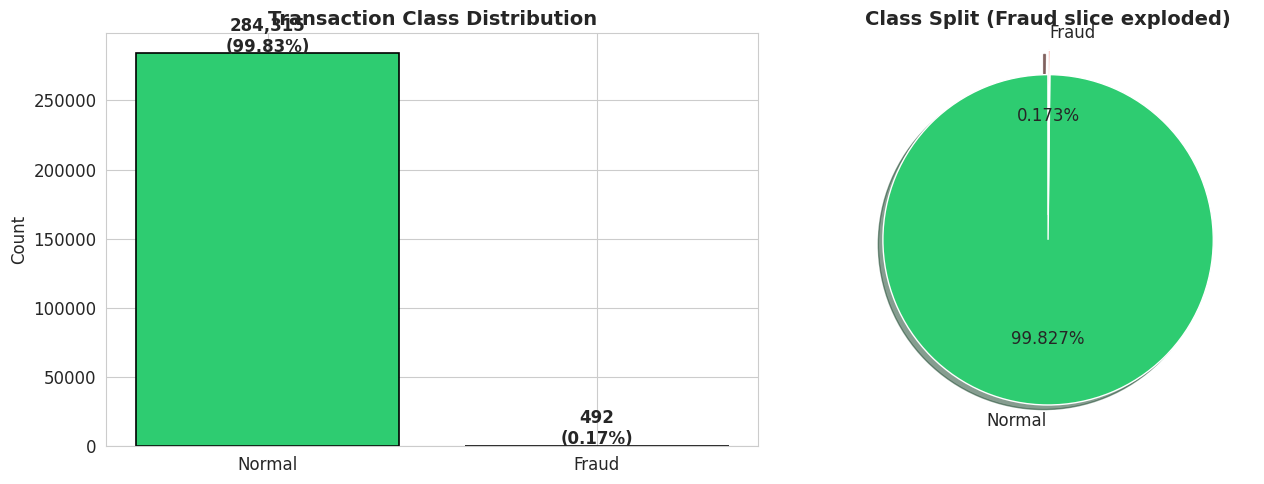


💡 KEY INSIGHT: Fraud is only 0.17% of all transactions.
   A naive model saying 'everything is normal' would be
   99.83% accurate — but USELESS. This is why we use
   anomaly detection + specialised metrics (not accuracy).


In [9]:
# ============================================================
# CELL 5: Visualise the class imbalance — this is the heart
#          of why this problem is hard
# ============================================================

fraud_count   = df['Class'].sum()                          # Number of fraud cases
normal_count  = len(df) - fraud_count                      # Number of normal cases
fraud_pct     = (fraud_count / len(df)) * 100

print("=" * 45)
print("       CLASS DISTRIBUTION")
print("=" * 45)
print(f"  Normal (Class=0) : {normal_count:,}  ({100-fraud_pct:.2f}%)")
print(f"  Fraud  (Class=1) : {fraud_count:,}    ({fraud_pct:.4f}%)")
print(f"  Imbalance Ratio  : {normal_count//fraud_count}:1")
print("=" * 45)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['Normal', 'Fraud'],
            [normal_count, fraud_count],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', linewidth=1.2)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([normal_count, fraud_count]):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.2f}%)',
                 ha='center', fontweight='bold')

# Pie chart (log scale to see the tiny fraud slice)
axes[1].pie([normal_count, fraud_count],
            labels=['Normal', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.3f%%',
            startangle=90,
            explode=(0, 0.15),        # Pull out the fraud slice for visibility
            shadow=True)
axes[1].set_title('Class Split (Fraud slice exploded)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 KEY INSIGHT: Fraud is only 0.17% of all transactions.")
print("   A naive model saying 'everything is normal' would be")
print("   99.83% accurate — but USELESS. This is why we use")
print("   anomaly detection + specialised metrics (not accuracy).")

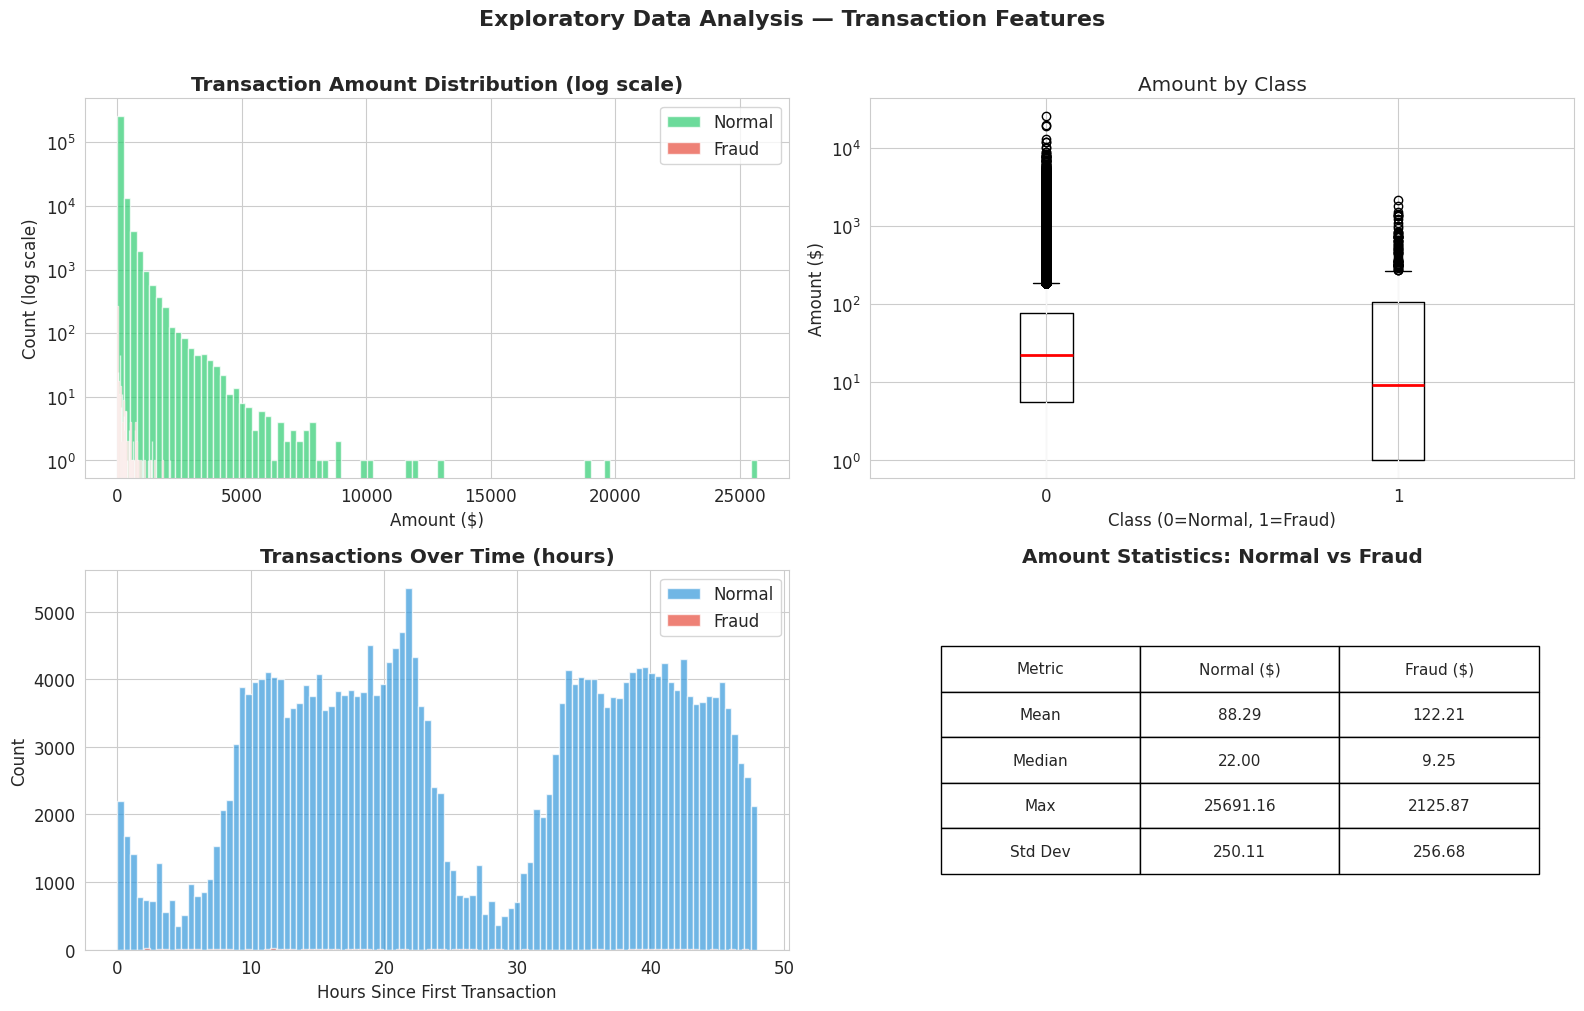

In [10]:
# ============================================================
# CELL 6: Analyse the Time and Amount features
#          (the only non-PCA columns we can interpret directly)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Transaction Amount ---
# Overall distribution (log scale because amounts are skewed)
axes[0, 0].hist(df[df['Class']==0]['Amount'], bins=100,
                color='#2ecc71', alpha=0.7, label='Normal', log=True)
axes[0, 0].hist(df[df['Class']==1]['Amount'], bins=100,
                color='#e74c3c', alpha=0.7, label='Fraud', log=True)
axes[0, 0].set_title('Transaction Amount Distribution (log scale)', fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Count (log scale)')
axes[0, 0].legend()

# Boxplot: Amount by class
df.boxplot(column='Amount', by='Class', ax=axes[0, 1],
           boxprops=dict(color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Amount by Class (Boxplot)', fontweight='bold')
axes[0, 1].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[0, 1].set_ylabel('Amount ($)')
axes[0, 1].set_yscale('log')
plt.sca(axes[0, 1])
plt.title('Amount by Class')

# --- Transaction Time ---
axes[1, 0].hist(df[df['Class']==0]['Time'] / 3600, bins=100,
                color='#3498db', alpha=0.7, label='Normal')
axes[1, 0].hist(df[df['Class']==1]['Time'] / 3600, bins=100,
                color='#e74c3c', alpha=0.7, label='Fraud')
axes[1, 0].set_title('Transactions Over Time (hours)', fontweight='bold')
axes[1, 0].set_xlabel('Hours Since First Transaction')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# Fraud amount stats
fraud_amounts = df[df['Class']==1]['Amount']
normal_amounts = df[df['Class']==0]['Amount']
stats_data = {
    'Metric': ['Mean', 'Median', 'Max', 'Std Dev'],
    'Normal ($)': [f"{normal_amounts.mean():.2f}",
                   f"{normal_amounts.median():.2f}",
                   f"{normal_amounts.max():.2f}",
                   f"{normal_amounts.std():.2f}"],
    'Fraud ($)':  [f"{fraud_amounts.mean():.2f}",
                   f"{fraud_amounts.median():.2f}",
                   f"{fraud_amounts.max():.2f}",
                   f"{fraud_amounts.std():.2f}"]
}
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=list(zip(stats_data['Metric'],
                                            stats_data['Normal ($)'],
                                            stats_data['Fraud ($)'])),
                          colLabels=['Metric', 'Normal ($)', 'Fraud ($)'],
                          cellLoc='center', loc='center',
                          bbox=[0.1, 0.2, 0.85, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
axes[1, 1].set_title('Amount Statistics: Normal vs Fraud', fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Transaction Features',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()

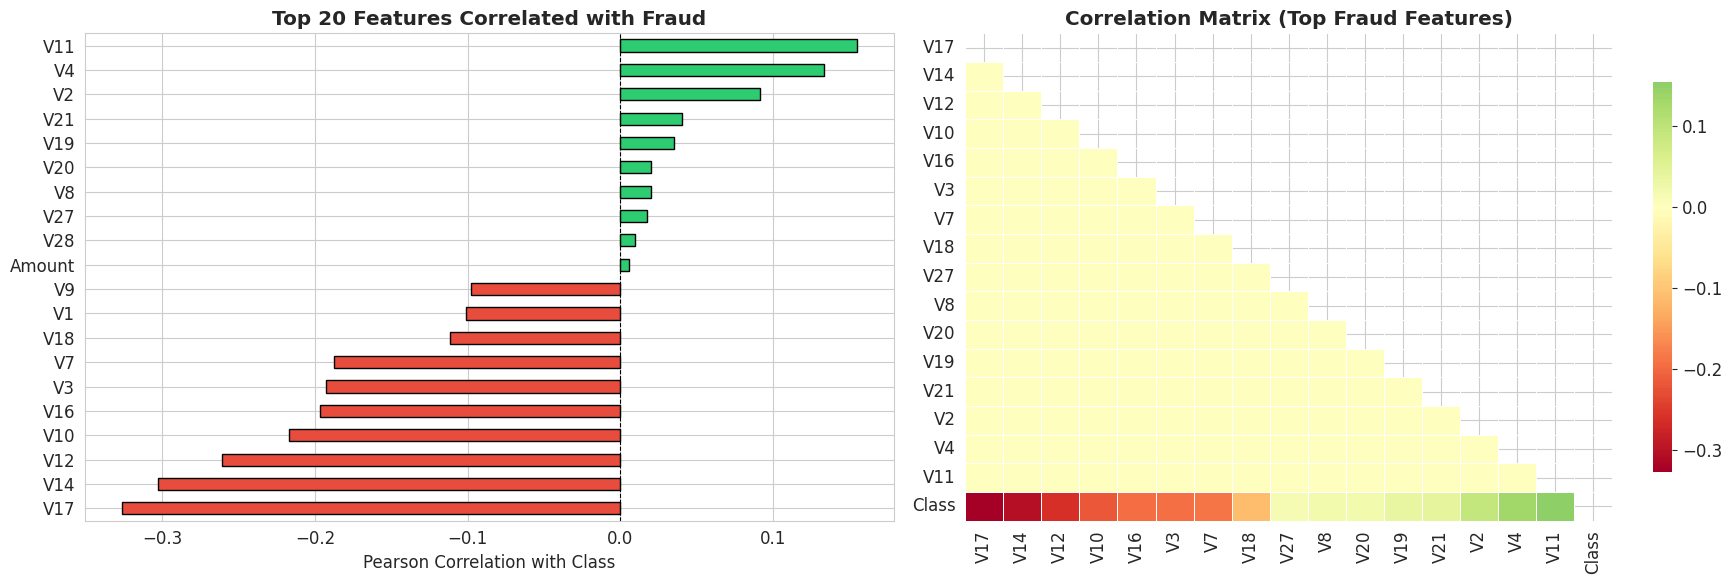


🔑 Most NEGATIVE correlations with fraud (fraud tends to be LOW):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539

🔑 Most POSITIVE correlations with fraud (fraud tends to be HIGH):
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876


In [11]:
# ============================================================
# CELL 7: Correlation heatmap — which V features are most
#          linked to fraud?
# ============================================================

# Compute correlation of every feature with the Class label
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Top correlated features ---
top_features = pd.concat([correlations.head(10), correlations.tail(10)])
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features.values]
top_features.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Top 20 Features Correlated with Fraud', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation with Class')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# --- Mini heatmap of top fraud-correlated features ---
top_cols = list(top_features.index[:8]) + list(top_features.index[-8:]) + ['Class']
corr_matrix = df[top_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask,
            cmap='RdYlGn', center=0, annot=False,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Matrix (Top Fraud Features)', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 Most NEGATIVE correlations with fraud (fraud tends to be LOW):")
print(correlations.head(5).to_string())
print("\n🔑 Most POSITIVE correlations with fraud (fraud tends to be HIGH):")
print(correlations.tail(5).to_string())

In [12]:
# ============================================================
# CELL 8: Import preprocessing tools
# ============================================================

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

print("✅ Preprocessing libraries ready!")

✅ Preprocessing libraries ready!


In [13]:
# ============================================================
# RECOVERY CELL — Run this whenever Colab disconnects
# It rebuilds all variables from scratch in ~30 seconds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# --- Step 1: Reload dataset ---
print("⏳ Loading dataset...")
df = pd.read_csv('creditcard.csv')
print(f"✅ df loaded — shape: {df.shape}")

# --- Step 2: Preprocessing ---
print("⏳ Preprocessing...")
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

df_processed = df.copy()
scaler = RobustScaler()
df_processed['Amount_scaled'] = scaler.fit_transform(df_processed[['Amount']])
df_processed['Time_scaled']   = scaler.fit_transform(df_processed[['Time']])
df_processed.drop(columns=['Amount', 'Time'], inplace=True)

X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

X_normal = X[y == 0]
X_fraud  = X[y == 1]
y_normal = y[y == 0]
y_fraud  = y[y == 1]

X_train, X_test_normal, y_train, y_test_normal = train_test_split(
    X_normal, y_normal, test_size=0.2, random_state=42
)

X_test = pd.concat([X_test_normal, X_fraud])
y_test = pd.concat([y_test_normal, y_fraud])

shuffle_idx = np.random.RandomState(42).permutation(len(X_test))
X_test = X_test.iloc[shuffle_idx].reset_index(drop=True)
y_test = y_test.iloc[shuffle_idx].reset_index(drop=True)

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ y_test  : {y_test.shape}")
print("\n🚀 All variables ready — continue from where you left off!")

⏳ Loading dataset...
✅ df loaded — shape: (284807, 31)
⏳ Preprocessing...
✅ X_train : (227452, 30)
✅ X_test  : (57355, 30)
✅ y_test  : (57355,)

🚀 All variables ready — continue from where you left off!


In [14]:
# ============================================================
# CELL 9: Scale Amount and Time features
#
# WHY RobustScaler?
# - Uses median and IQR instead of mean and std
# - Not affected by outliers (fraud transactions ARE outliers!)
# - StandardScaler would be distorted by extreme fraud amounts
# ============================================================

df = pd.read_csv('creditcard.csv') # Re-load df to ensure it's defined
df_processed = df.copy()   # Always work on a copy, never modify raw data

scaler = RobustScaler()

# Only scale Amount and Time — V1-V28 are already scaled from PCA
df_processed['Amount_scaled'] = scaler.fit_transform(df_processed[['Amount']])
df_processed['Time_scaled']   = scaler.fit_transform(df_processed[['Time']])

# Drop the original unscaled columns (we don't need them anymore)
df_processed.drop(columns=['Amount', 'Time'], inplace=True);

print("✅ Scaling complete!")
print(f"\nAmount_scaled — mean: {df_processed['Amount_scaled'].mean():.4f}, "
      f"std: {df_processed['Amount_scaled'].std():.4f}")
print(f"Time_scaled   — mean: {df_processed['Time_scaled'].mean():.4f}, "
      f"std: {df_processed['Time_scaled'].std():.4f}")
print(f"\nDataset shape after processing: {df_processed.shape}")
print(f"Columns: {list(df_processed.columns[:5])} ... {list(df_processed.columns[-3:])}")

✅ Scaling complete!

Amount_scaled — mean: 0.9271, std: 3.4950
Time_scaled   — mean: 0.1189, std: 0.5579

Dataset shape after processing: (284807, 31)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5'] ... ['Class', 'Amount_scaled', 'Time_scaled']


In [15]:
# ============================================================
# CELL 10: Separate features from labels
# ============================================================

# Features — everything except the Class column
X = df_processed.drop(columns=['Class'])

# Labels — kept aside ONLY for evaluation (not used in training)
y = df_processed['Class']

print(f"Features matrix X shape : {X.shape}")
print(f"Labels vector  y shape  : {y.shape}")
print(f"\nFeature columns ({len(X.columns)} total):")
print(list(X.columns))

Features matrix X shape : (284807, 30)
Labels vector  y shape  : (284807,)

Feature columns (30 total):
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


In [16]:
# ============================================================
# CELL 11: The anomaly detection train/test split
#
# Strategy:
#   - Train set  : normal transactions only (model learns "normal")
#   - Test set   : mix of normal + ALL fraud (model gets evaluated)
# ============================================================

# Separate normal and fraud rows
X_normal = X[y == 0]
X_fraud  = X[y == 1]
y_normal = y[y == 0]
y_fraud  = y[y == 1]

print(f"Normal transactions : {len(X_normal):,}")
print(f"Fraud  transactions : {len(X_fraud):,}")

# Split NORMAL data into 80% train, 20% test
X_train, X_test_normal, y_train, y_test_normal = train_test_split(
    X_normal, y_normal,
    test_size=0.2,
    random_state=42          # Fixed seed = reproducible results
)

# Test set = normal (20%) + ALL fraud combined
X_test = pd.concat([X_test_normal, X_fraud])
y_test = pd.concat([y_test_normal, y_fraud])

# Shuffle the test set so fraud isn't all at the end
shuffle_idx = np.random.RandomState(42).permutation(len(X_test))
X_test = X_test.iloc[shuffle_idx].reset_index(drop=True)
y_test = y_test.iloc[shuffle_idx].reset_index(drop=True)

print("\n" + "=" * 50)
print("         FINAL SPLIT SUMMARY")
print("=" * 50)
print(f"  Training set   : {len(X_train):,} transactions")
print(f"    → All normal (model learns 'normal')")
print(f"\n  Test set       : {len(X_test):,} transactions")
print(f"    → Normal : {len(y_test[y_test==0]):,}")
print(f"    → Fraud  : {len(y_test[y_test==1]):,}")
print(f"    → Fraud% : {y_test.mean()*100:.2f}%")
print("=" * 50)

Normal transactions : 284,315
Fraud  transactions : 492

         FINAL SPLIT SUMMARY
  Training set   : 227,452 transactions
    → All normal (model learns 'normal')

  Test set       : 57,355 transactions
    → Normal : 56,863
    → Fraud  : 492
    → Fraud% : 0.86%


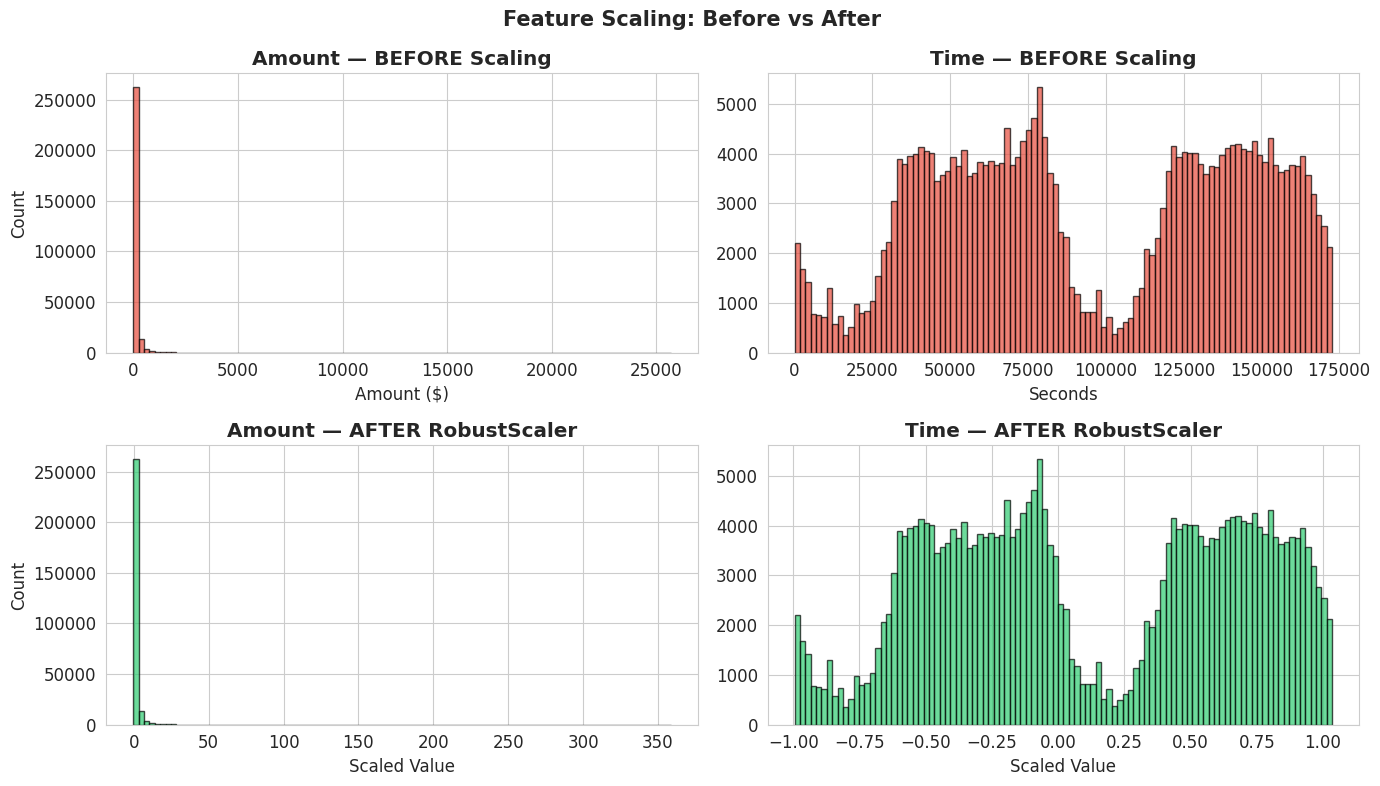

In [17]:
# ============================================================
# CELL 12: Verify scaling worked — visual check
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Before scaling
axes[0, 0].hist(df['Amount'], bins=100, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Amount — BEFORE Scaling', fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['Time'], bins=100, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Time — BEFORE Scaling', fontweight='bold')
axes[0, 1].set_xlabel('Seconds')

# After scaling
axes[1, 0].hist(df_processed['Amount_scaled'], bins=100,
                color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Amount — AFTER RobustScaler', fontweight='bold')
axes[1, 0].set_xlabel('Scaled Value')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(df_processed['Time_scaled'], bins=100,
                color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Time — AFTER RobustScaler', fontweight='bold')
axes[1, 1].set_xlabel('Scaled Value')

plt.suptitle('Feature Scaling: Before vs After', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# CELL 13: Save everything so we don't lose it
#           (Google Colab disconnects after ~90 min idle)
# ============================================================

import pickle

# Save processed arrays
with open('data_splits.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_test': y_test,
        'X_fraud': X_fraud,
        'X_normal': X_normal,
        'feature_names': list(X.columns)
    }, f)

print("✅ All data splits saved to data_splits.pkl")
print("\n📌 QUICK REFERENCE — Variables to remember:")
print(f"   X_train : {X_train.shape}  ← feed this to models for training")
print(f"   X_test  : {X_test.shape}  ← evaluate models on this")
print(f"   y_test  : {y_test.shape}  ← ground truth labels for evaluation")

✅ All data splits saved to data_splits.pkl

📌 QUICK REFERENCE — Variables to remember:
   X_train : (227452, 30)  ← feed this to models for training
   X_test  : (57355, 30)  ← evaluate models on this
   y_test  : (57355,)  ← ground truth labels for evaluation


In [19]:
# ============================================================
# CELL 14: Train the Isolation Forest model
# ============================================================

from sklearn.ensemble import IsolationForest
import time

print("🌲 Training Isolation Forest...")
print("   (This should take 10–30 seconds)\n")

start_time = time.time()

iso_forest = IsolationForest(
    n_estimators=100,       # Number of trees — more = more stable, but slower
    max_samples='auto',     # Samples per tree (auto = min(256, n_samples))
    contamination=0.001722, # Expected fraud rate — we calculated this from EDA!
                            # = 492 / 284807 = 0.001722
    random_state=42,        # Reproducibility
    n_jobs=-1               # Use all CPU cores
)

# ⚠️ IMPORTANT: Train on X_train ONLY (normal data)
# The model learns what "normal" looks like
iso_forest.fit(X_train)

elapsed = time.time() - start_time
print(f"✅ Training complete in {elapsed:.1f} seconds!")
print(f"\nModel parameters:")
print(f"  Trees (n_estimators) : {iso_forest.n_estimators}")
print(f"  Contamination        : {iso_forest.contamination}")
print(f"  Training samples     : {len(X_train):,}")

🌲 Training Isolation Forest...
   (This should take 10–30 seconds)

✅ Training complete in 2.0 seconds!

Model parameters:
  Trees (n_estimators) : 100
  Contamination        : 0.001722
  Training samples     : 227,452


In [20]:
# ============================================================
# CELL 15: Generate predictions on the test set
#
# Isolation Forest outputs TWO things:
#   predict()        → binary label:  1 = normal, -1 = anomaly
#   score_samples()  → anomaly score: more negative = more anomalous
# ============================================================

# Binary predictions (-1 = anomaly, +1 = normal)
if_raw_preds = iso_forest.predict(X_test)

# Convert to 0/1 to match our y_test labels (0=normal, 1=fraud)
# Isolation Forest uses: +1 = normal, -1 = anomaly
# We need:               0  = normal,  1 = fraud
if_labels = np.where(if_raw_preds == -1, 1, 0)

# Anomaly scores (we'll use these for AUC-ROC — more negative = more suspicious)
if_scores = iso_forest.score_samples(X_test)
# Flip sign so that HIGHER score = MORE anomalous (easier to interpret)
if_scores_flipped = -if_scores

print("Prediction distribution:")
unique, counts = np.unique(if_labels, return_counts=True)
for label, count in zip(unique, counts):
    name = "Normal" if label == 0 else "Fraud"
    print(f"  Predicted {name:6} ({label}): {count:,} ({count/len(if_labels)*100:.2f}%)")

print(f"\nAnomaly score range: {if_scores_flipped.min():.4f} to {if_scores_flipped.max():.4f}")
print("(Higher score = model thinks it's more anomalous)")

Prediction distribution:
  Predicted Normal (0): 57,150 (99.64%)
  Predicted Fraud  (1): 205 (0.36%)

Anomaly score range: 0.3495 to 0.7731
(Higher score = model thinks it's more anomalous)


In [21]:
# ============================================================
# CELL 16: Evaluate the model — PROPER metrics for imbalanced data
#
# WHY NOT ACCURACY?
#   Predicting "all normal" = 99.14% accuracy on test set
#   That's useless. We use:
#
#   Precision  = Of all flagged fraud, how many were real fraud?
#                (Low precision = too many false alarms)
#   Recall     = Of all real fraud, how many did we catch?
#                (Low recall = missing actual fraud — dangerous!)
#   F1 Score   = Harmonic mean of precision & recall
#   AUC-ROC    = Overall ranking ability (0.5 = random, 1.0 = perfect)
# ============================================================

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

print("=" * 55)
print("     ISOLATION FOREST — EVALUATION RESULTS")
print("=" * 55)

# Core metrics
auc_roc = roc_auc_score(y_test, if_scores_flipped)
auc_pr  = average_precision_score(y_test, if_scores_flipped)

print(f"\n  AUC-ROC Score          : {auc_roc:.4f}")
print(f"  AUC-PR Score           : {auc_pr:.4f}")
print(f"\n  (AUC-ROC: 0.5=random, 1.0=perfect)")
print(f"  (AUC-PR:  harder metric, better for imbalanced data)")

print("\n--- Classification Report ---")
print(classification_report(y_test, if_labels,
                             target_names=['Normal', 'Fraud']))

     ISOLATION FOREST — EVALUATION RESULTS

  AUC-ROC Score          : 0.9494
  AUC-PR Score           : 0.3516

  (AUC-ROC: 0.5=random, 1.0=perfect)
  (AUC-PR:  harder metric, better for imbalanced data)

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     56863
       Fraud       0.57      0.24      0.33       492

    accuracy                           0.99     57355
   macro avg       0.78      0.62      0.66     57355
weighted avg       0.99      0.99      0.99     57355



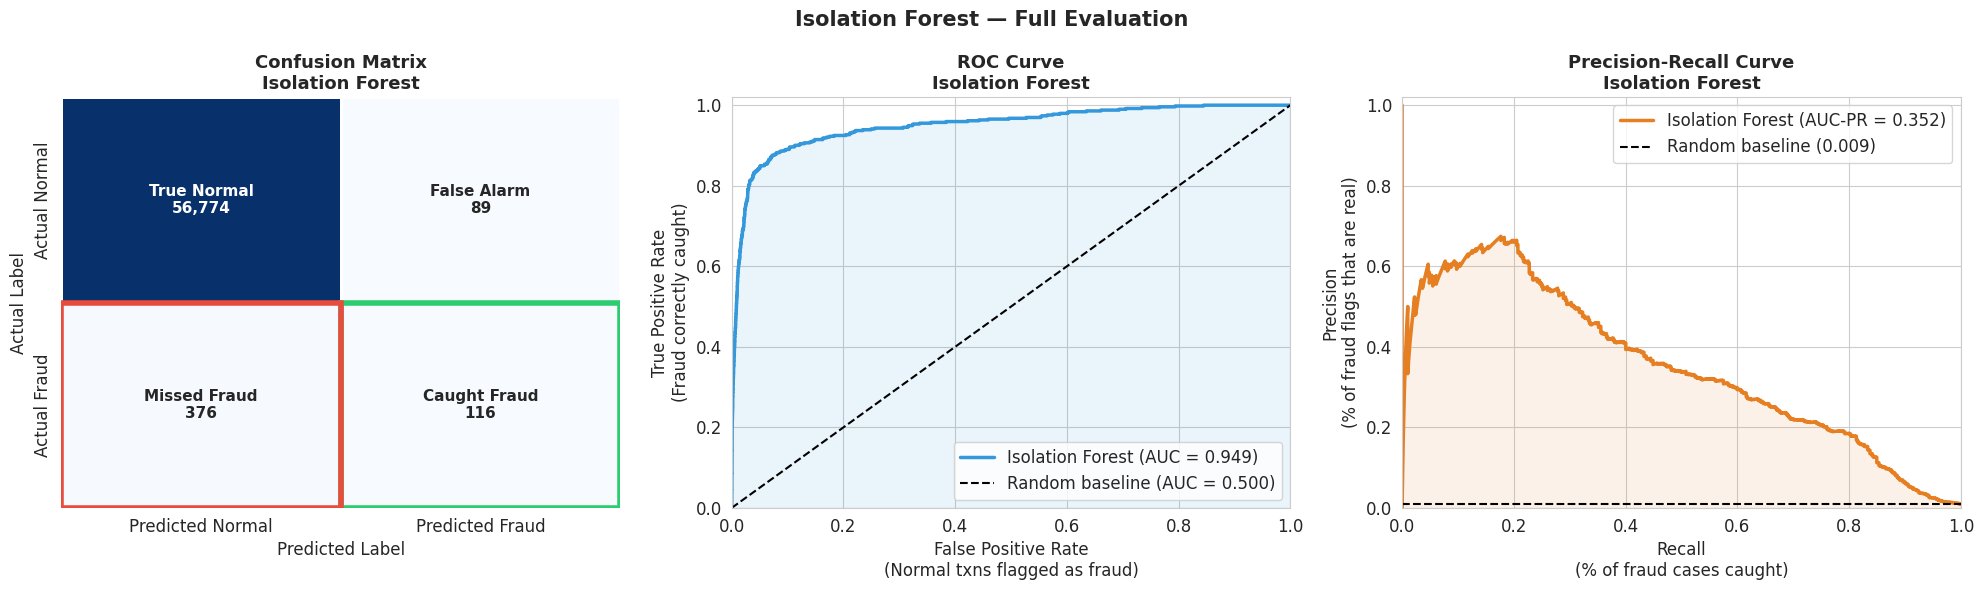

In [22]:
# ============================================================
# CELL 17: Visualise results — Confusion Matrix + ROC Curve
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, if_labels)
labels = np.array([
    [f"True Normal\n{cm[0,0]:,}", f"False Alarm\n{cm[0,1]:,}"],
    [f"Missed Fraud\n{cm[1,0]:,}", f"Caught Fraud\n{cm[1,1]:,}"]
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            ax=axes[0], linewidths=2, linecolor='white',
            cbar=False, annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title('Confusion Matrix\nIsolation Forest', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Colour the key cells
axes[0].add_patch(plt.Rectangle((1,1), 1, 1, fill=False,
                                  edgecolor='#2ecc71', lw=4))   # Caught fraud = green border
axes[0].add_patch(plt.Rectangle((0,1), 1, 1, fill=False,
                                  edgecolor='#e74c3c', lw=4))   # Missed fraud = red border

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, if_scores_flipped)
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5,
             label=f'Isolation Forest (AUC = {auc_roc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1.5, label='Random baseline (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate\n(Normal txns flagged as fraud)')
axes[1].set_ylabel('True Positive Rate\n(Fraud correctly caught)')
axes[1].set_title('ROC Curve\nIsolation Forest', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

# --- 3. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, if_scores_flipped)
axes[2].plot(recall, precision, color='#e67e22', lw=2.5,
             label=f'Isolation Forest (AUC-PR = {auc_pr:.3f})')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1.5,
                label=f'Random baseline ({y_test.mean():.3f})')
axes[2].fill_between(recall, precision, alpha=0.1, color='#e67e22')
axes[2].set_xlabel('Recall\n(% of fraud cases caught)')
axes[2].set_ylabel('Precision\n(% of fraud flags that are real)')
axes[2].set_title('Precision-Recall Curve\nIsolation Forest', fontweight='bold', fontsize=13)
axes[2].legend(loc='upper right')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.suptitle('Isolation Forest — Full Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

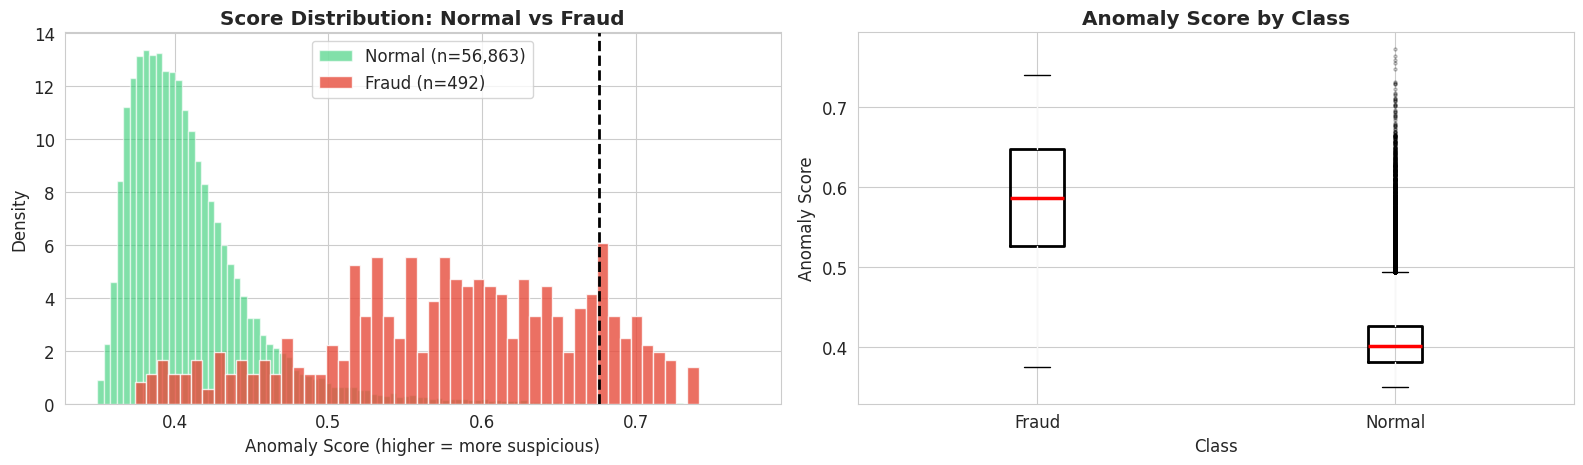


Score Statistics:
  Normal — mean: 0.4099, median: 0.4004
  Fraud  — mean: 0.5810,  median: 0.5866

💡 The higher fraud scores show the model IS separating them —
   even though it never saw fraud during training!


In [23]:
# ============================================================
# CELL 18: Anomaly score distribution — see the separation
#          between normal and fraud scores visually
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

normal_scores = if_scores_flipped[y_test == 0]
fraud_scores  = if_scores_flipped[y_test == 1]

# --- Score distributions ---
axes[0].hist(normal_scores, bins=100, alpha=0.6,
             color='#2ecc71', label=f'Normal (n={len(normal_scores):,})', density=True)
axes[0].hist(fraud_scores,  bins=50,  alpha=0.8,
             color='#e74c3c', label=f'Fraud (n={len(fraud_scores):,})',  density=True)
axes[0].set_xlabel('Anomaly Score (higher = more suspicious)')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution: Normal vs Fraud', fontweight='bold')
axes[0].legend()
axes[0].axvline(np.percentile(if_scores_flipped, 99.8),
                color='black', linestyle='--', linewidth=2,
                label='99.8th percentile threshold')

# --- Score box plot ---
score_df = pd.DataFrame({
    'Score': np.concatenate([normal_scores, fraud_scores]),
    'Class': ['Normal'] * len(normal_scores) + ['Fraud'] * len(fraud_scores)
})
score_df.boxplot(column='Score', by='Class', ax=axes[1],
                 boxprops=dict(color='black', linewidth=2),
                 medianprops=dict(color='red', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Anomaly Score by Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Anomaly Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('if_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nScore Statistics:")
print(f"  Normal — mean: {normal_scores.mean():.4f}, median: {np.median(normal_scores):.4f}")
print(f"  Fraud  — mean: {fraud_scores.mean():.4f},  median: {np.median(fraud_scores):.4f}")
print(f"\n💡 The higher fraud scores show the model IS separating them —")
print(f"   even though it never saw fraud during training!")

In [24]:
# ============================================================
# CELL 19: Save results for the final model comparison table
# ============================================================

# We'll collect all model results here throughout the project
results = {}
results['Isolation Forest'] = {
    'auc_roc'  : round(roc_auc_score(y_test, if_scores_flipped), 4),
    'auc_pr'   : round(average_precision_score(y_test, if_scores_flipped), 4),
    'precision': round(confusion_matrix(y_test, if_labels)[1,1] /
                       (if_labels == 1).sum(), 4),
    'recall'   : round(confusion_matrix(y_test, if_labels)[1,1] / 492, 4),
    'caught'   : int(confusion_matrix(y_test, if_labels)[1,1]),
    'missed'   : int(confusion_matrix(y_test, if_labels)[1,0]),
}

print("📊 Results saved for final comparison:")
print(f"   AUC-ROC   : {results['Isolation Forest']['auc_roc']}")
print(f"   AUC-PR    : {results['Isolation Forest']['auc_pr']}")
print(f"   Fraud caught : {results['Isolation Forest']['caught']} / 492")
print(f"   Fraud missed : {results['Isolation Forest']['missed']} / 492")

# Persist to disk
with open('model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\n✅ Saved to model_results.pkl")

📊 Results saved for final comparison:
   AUC-ROC   : 0.9494
   AUC-PR    : 0.3516
   Fraud caught : 116 / 492
   Fraud missed : 376 / 492

✅ Saved to model_results.pkl


In [25]:
# ============================================================
# CELL 20: Prepare a sample for One-Class SVM
# ============================================================

from sklearn.svm import OneClassSVM
import time

# Sample 10,000 normal transactions for training
# (One-Class SVM doesn't scale well to 200k+ rows)
SAMPLE_SIZE = 10_000

np.random.seed(42)
sample_idx = np.random.choice(len(X_train), size=SAMPLE_SIZE, replace=False)
X_train_sample = X_train.iloc[sample_idx]

print(f"Full training set    : {len(X_train):,} rows")
print(f"Sampled training set : {len(X_train_sample):,} rows")
print(f"\n💡 Why sample? One-Class SVM training time scales as O(n²).")
print(f"   10k rows ≈ 30 seconds vs 227k rows ≈ 30+ minutes.")
print(f"   10k is enough to learn the 'normal' boundary well.")

Full training set    : 227,452 rows
Sampled training set : 10,000 rows

💡 Why sample? One-Class SVM training time scales as O(n²).
   10k rows ≈ 30 seconds vs 227k rows ≈ 30+ minutes.
   10k is enough to learn the 'normal' boundary well.


In [26]:
# ============================================================
# CELL 21: Train One-Class SVM
#
# Key parameters:
#   kernel = 'rbf'  → Radial Basis Function — best for non-linear
#                      boundaries (fraud is never linearly separable)
#   nu     = 0.01   → ~1% of training data allowed as outliers
#   gamma  = 'scale'→ auto-sets based on feature variance
# ============================================================

print("🔵 Training One-Class SVM...")
print("   (This should take 20–60 seconds on 10k samples)\n")

start_time = time.time()

oc_svm = OneClassSVM(
    kernel='rbf',       # RBF kernel = curved decision boundary
    nu=0.01,            # Expect ~1% anomalies in training data
    gamma='scale'       # gamma = 1 / (n_features * X.var())
)

oc_svm.fit(X_train_sample)

elapsed = time.time() - start_time
print(f"✅ Training complete in {elapsed:.1f} seconds!")

🔵 Training One-Class SVM...
   (This should take 20–60 seconds on 10k samples)

✅ Training complete in 0.3 seconds!


In [27]:
# ============================================================
# CELL 22: Generate predictions
#
# One-Class SVM also outputs:
#   predict()         →  1 = normal, -1 = anomaly (same as IF)
#   decision_function()→ signed distance from boundary
#                         negative = outside boundary = anomaly
# ============================================================

print("⏳ Generating predictions on test set...")
print("   (May take 1–2 minutes for 57k test rows)\n")

start_time = time.time()

# Binary predictions
svm_raw_preds = oc_svm.predict(X_test)
svm_labels    = np.where(svm_raw_preds == -1, 1, 0)  # Convert to 0/1

# Anomaly scores (negative distance = more anomalous)
svm_scores        = oc_svm.decision_function(X_test)
svm_scores_flipped = -svm_scores   # Flip: higher = more anomalous

elapsed = time.time() - start_time
print(f"✅ Predictions done in {elapsed:.1f} seconds!")

print("\nPrediction distribution:")
unique, counts = np.unique(svm_labels, return_counts=True)
for label, count in zip(unique, counts):
    name = "Normal" if label == 0 else "Fraud"
    print(f"  Predicted {name:6} ({label}): {count:,} ({count/len(svm_labels)*100:.2f}%)")

⏳ Generating predictions on test set...
   (May take 1–2 minutes for 57k test rows)

✅ Predictions done in 3.7 seconds!

Prediction distribution:
  Predicted Normal (0): 55,069 (96.01%)
  Predicted Fraud  (1): 2,286 (3.99%)


In [28]:
# ============================================================
# CELL 23: Evaluate One-Class SVM
# ============================================================

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

print("=" * 55)
print("     ONE-CLASS SVM — EVALUATION RESULTS")
print("=" * 55)

svm_auc_roc = roc_auc_score(y_test, svm_scores_flipped)
svm_auc_pr  = average_precision_score(y_test, svm_scores_flipped)

print(f"\n  AUC-ROC Score : {svm_auc_roc:.4f}")
print(f"  AUC-PR Score  : {svm_auc_pr:.4f}")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, svm_labels,
                             target_names=['Normal', 'Fraud']))

     ONE-CLASS SVM — EVALUATION RESULTS

  AUC-ROC Score : 0.9442
  AUC-PR Score  : 0.6054

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     56863
       Fraud       0.19      0.88      0.31       492

    accuracy                           0.97     57355
   macro avg       0.59      0.92      0.65     57355
weighted avg       0.99      0.97      0.98     57355



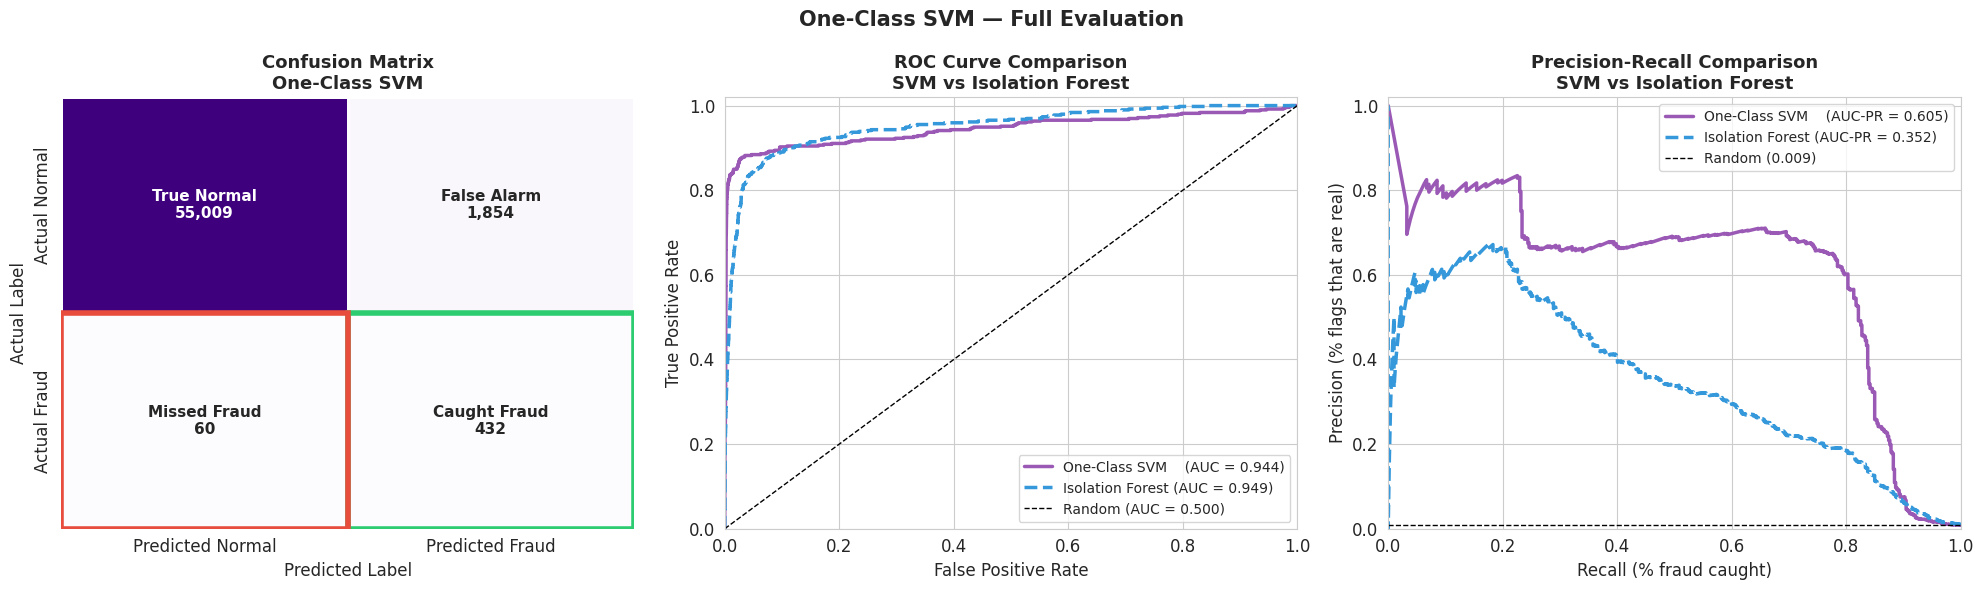

In [29]:
# ============================================================
# CELL 24: Visualise — Confusion Matrix + ROC + PR curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. Confusion Matrix ---
cm_svm = confusion_matrix(y_test, svm_labels)
labels_cm = np.array([
    [f"True Normal\n{cm_svm[0,0]:,}", f"False Alarm\n{cm_svm[0,1]:,}"],
    [f"Missed Fraud\n{cm_svm[1,0]:,}", f"Caught Fraud\n{cm_svm[1,1]:,}"]
])
sns.heatmap(cm_svm, annot=labels_cm, fmt='', cmap='Purples',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            ax=axes[0], linewidths=2, linecolor='white',
            cbar=False, annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title('Confusion Matrix\nOne-Class SVM', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')
axes[0].add_patch(plt.Rectangle((1,1), 1, 1, fill=False,
                                  edgecolor='#2ecc71', lw=4))
axes[0].add_patch(plt.Rectangle((0,1), 1, 1, fill=False,
                                  edgecolor='#e74c3c', lw=4))

# --- 2. ROC Curve ---
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores_flipped)
fpr_if,  tpr_if,  _ = roc_curve(y_test, if_scores_flipped)

axes[1].plot(fpr_svm, tpr_svm, color='#9b59b6', lw=2.5,
             label=f'One-Class SVM    (AUC = {svm_auc_roc:.3f})')
axes[1].plot(fpr_if,  tpr_if,  color='#3498db', lw=2.5, linestyle='--',
             label=f'Isolation Forest (AUC = {results["Isolation Forest"]["auc_roc"]:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison\nSVM vs Isolation Forest',
                  fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

# --- 3. Precision-Recall Curve ---
prec_svm, rec_svm, _ = precision_recall_curve(y_test, svm_scores_flipped)
prec_if,  rec_if,  _ = precision_recall_curve(y_test, if_scores_flipped)

axes[2].plot(rec_svm, prec_svm, color='#9b59b6', lw=2.5,
             label=f'One-Class SVM    (AUC-PR = {svm_auc_pr:.3f})')
axes[2].plot(rec_if,  prec_if,  color='#3498db', lw=2.5, linestyle='--',
             label=f'Isolation Forest (AUC-PR = {results["Isolation Forest"]["auc_pr"]:.3f})')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Random ({y_test.mean():.3f})')
axes[2].set_xlabel('Recall (% fraud caught)')
axes[2].set_ylabel('Precision (% flags that are real)')
axes[2].set_title('Precision-Recall Comparison\nSVM vs Isolation Forest',
                  fontweight='bold', fontsize=13)
axes[2].legend(loc='upper right', fontsize=10)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.suptitle('One-Class SVM — Full Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('ocsvm_results.png', dpi=150, bbox_inches='tight')
plt.show()

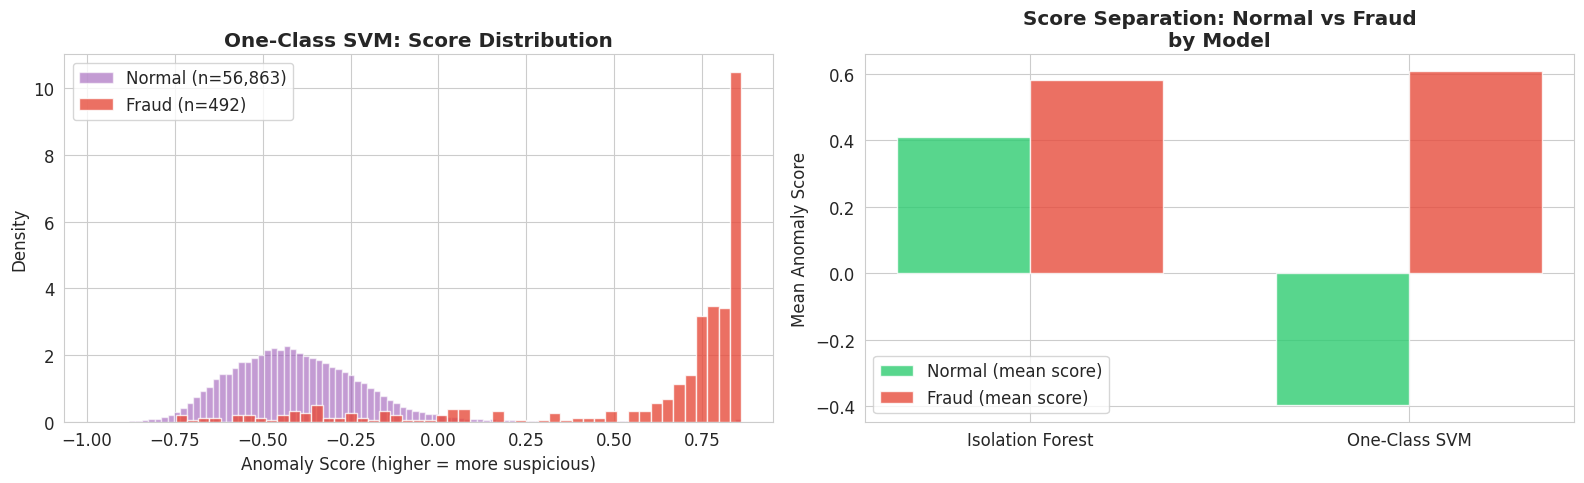


Score Separation:
  Isolation Forest — Normal: 0.4099 | Fraud: 0.5810
  One-Class SVM   — Normal: -0.3960 | Fraud: 0.6083


In [30]:
# ============================================================
# CELL 25: Score distribution — how well does SVM separate?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

normal_svm_scores = svm_scores_flipped[y_test == 0]
fraud_svm_scores  = svm_scores_flipped[y_test == 1]

# Distribution plot
axes[0].hist(normal_svm_scores, bins=100, alpha=0.6,
             color='#9b59b6', label=f'Normal (n={len(normal_svm_scores):,})',
             density=True)
axes[0].hist(fraud_svm_scores, bins=50, alpha=0.8,
             color='#e74c3c', label=f'Fraud (n={len(fraud_svm_scores):,})',
             density=True)
axes[0].set_xlabel('Anomaly Score (higher = more suspicious)')
axes[0].set_ylabel('Density')
axes[0].set_title('One-Class SVM: Score Distribution', fontweight='bold')
axes[0].legend()

# Side-by-side comparison: IF vs SVM separation
separation_data = {
    'Model': ['Isolation Forest', 'One-Class SVM'],
    'Normal Score (mean)': [
        -if_scores_flipped[y_test==0].mean(),
        -svm_scores_flipped[y_test==0].mean()
    ],
    'Fraud Score (mean)': [
        -if_scores_flipped[y_test==1].mean(),
        -svm_scores_flipped[y_test==1].mean()
    ]
}

x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2,
            [if_scores_flipped[y_test==0].mean(),
             svm_scores_flipped[y_test==0].mean()],
            width, label='Normal (mean score)', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2,
            [if_scores_flipped[y_test==1].mean(),
             svm_scores_flipped[y_test==1].mean()],
            width, label='Fraud (mean score)', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Isolation Forest', 'One-Class SVM'])
axes[1].set_ylabel('Mean Anomaly Score')
axes[1].set_title('Score Separation: Normal vs Fraud\nby Model', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('svm_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nScore Separation:")
print(f"  Isolation Forest — Normal: {if_scores_flipped[y_test==0].mean():.4f} | "
      f"Fraud: {if_scores_flipped[y_test==1].mean():.4f}")
print(f"  One-Class SVM   — Normal: {svm_scores_flipped[y_test==0].mean():.4f} | "
      f"Fraud: {svm_scores_flipped[y_test==1].mean():.4f}")

In [31]:
# ============================================================
# CELL 26: Save SVM results to comparison table
# ============================================================

cm_svm = confusion_matrix(y_test, svm_labels)

results['One-Class SVM'] = {
    'auc_roc'  : round(svm_auc_roc, 4),
    'auc_pr'   : round(svm_auc_pr, 4),
    'precision': round(cm_svm[1,1] / (svm_labels == 1).sum(), 4)
                 if (svm_labels == 1).sum() > 0 else 0,
    'recall'   : round(cm_svm[1,1] / 492, 4),
    'caught'   : int(cm_svm[1,1]),
    'missed'   : int(cm_svm[1,0]),
}

# Quick mid-project leaderboard
print("=" * 52)
print("     📊 MID-PROJECT LEADERBOARD")
print("=" * 52)
print(f"  {'Model':<22} {'AUC-ROC':>8} {'AUC-PR':>8} {'Caught':>8}")
print(f"  {'-'*48}")
for model, r in results.items():
    print(f"  {model:<22} {r['auc_roc']:>8.4f} "
          f"{r['auc_pr']:>8.4f} {r['caught']:>5}/492")
print(f"  {'-'*48}")
print(f"  {'Random Baseline':<22} {'0.5000':>8} {'0.0086':>8} {'?':>8}")
print("=" * 52)

# Save updated results
with open('model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\n✅ Results saved!")

     📊 MID-PROJECT LEADERBOARD
  Model                   AUC-ROC   AUC-PR   Caught
  ------------------------------------------------
  Isolation Forest         0.9494   0.3516   116/492
  One-Class SVM            0.9442   0.6054   432/492
  ------------------------------------------------
  Random Baseline          0.5000   0.0086        ?

✅ Results saved!


In [32]:
# ============================================================
# CELL 27: Import TensorFlow and set up environment
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
import time

# Check GPU availability (Colab gives you a free GPU!)
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

if len(tf.config.list_physical_devices('GPU')) > 0:
    print("✅ GPU detected — training will be fast!")
else:
    print("⚠️  No GPU — go to Runtime → Change Runtime Type → GPU")

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("\n✅ TensorFlow ready!")

TensorFlow version : 2.20.0
GPU available      : False
⚠️  No GPU — go to Runtime → Change Runtime Type → GPU

✅ TensorFlow ready!


In [33]:
# ============================================================
# CELL 28: Convert data to numpy arrays for TensorFlow
#
# TensorFlow works with numpy arrays, not pandas DataFrames
# ============================================================

X_train_np = X_train.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.int32)

print(f"X_train_np shape : {X_train_np.shape}")
print(f"X_test_np  shape : {X_test_np.shape}")
print(f"Data type        : {X_train_np.dtype}")
print(f"Value range      : {X_train_np.min():.2f} to {X_train_np.max():.2f}")
print("\n✅ Data converted to numpy arrays!")

X_train_np shape : (227452, 30)
X_test_np  shape : (57355, 30)
Data type        : float32
Value range      : -73.22 to 274.36

✅ Data converted to numpy arrays!


In [34]:
# ============================================================
# CELL 29: Build the Autoencoder architecture
#
# We build it as two separate pieces:
#   1. Full autoencoder  → used for training
#   2. Encoder only      → used to visualise compressed representations
# ============================================================

INPUT_DIM  = X_train_np.shape[1]   # 30 features
ENCODING_1 = 16                     # First compression layer
ENCODING_2 = 8                      # Second compression layer
BOTTLENECK = 4                      # Smallest layer — the "essence"

def build_autoencoder(input_dim, enc1, enc2, bottleneck):
    """
    Builds a symmetric autoencoder:
    Encoder: input_dim → enc1 → enc2 → bottleneck
    Decoder: bottleneck → enc2 → enc1 → input_dim
    """

    # --- INPUT ---
    inputs = keras.Input(shape=(input_dim,), name='input_layer')

    # --- ENCODER ---
    # Each layer learns increasingly abstract representations
    x = layers.Dense(enc1, activation='relu', name='encoder_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)       # Stabilises training
    x = layers.Dropout(0.1, name='dropout_1')(x)        # Prevents memorisation

    x = layers.Dense(enc2, activation='relu', name='encoder_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.1, name='dropout_2')(x)

    # --- BOTTLENECK ---
    bottleneck_layer = layers.Dense(bottleneck, activation='relu',
                                    name='bottleneck')(x)

    # --- DECODER ---
    # Mirror of encoder — reconstructs back to original size
    x = layers.Dense(enc2, activation='relu', name='decoder_1')(bottleneck_layer)
    x = layers.BatchNormalization(name='bn_3')(x)

    x = layers.Dense(enc1, activation='relu', name='decoder_2')(x)
    x = layers.BatchNormalization(name='bn_4')(x)

    # --- OUTPUT ---
    # Linear activation — output can be any value (not just 0-1)
    outputs = layers.Dense(input_dim, activation='linear',
                           name='output_layer')(x)

    # --- BUILD MODELS ---
    autoencoder = Model(inputs, outputs, name='autoencoder')
    encoder     = Model(inputs, bottleneck_layer, name='encoder')

    return autoencoder, encoder


autoencoder, encoder = build_autoencoder(INPUT_DIM, ENCODING_1,
                                          ENCODING_2, BOTTLENECK)

# Compile — we use MSE loss because we're measuring reconstruction error
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',           # Mean Squared Error = reconstruction quality
    metrics=['mae']       # Mean Absolute Error — easier to interpret
)

print("✅ Autoencoder built!\n")
autoencoder.summary()

✅ Autoencoder built!



Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,554 (6.07 KB)

 Trainable params: 1,458 (5.70 KB)

 Non-trainable params: 96 (384.00 B)

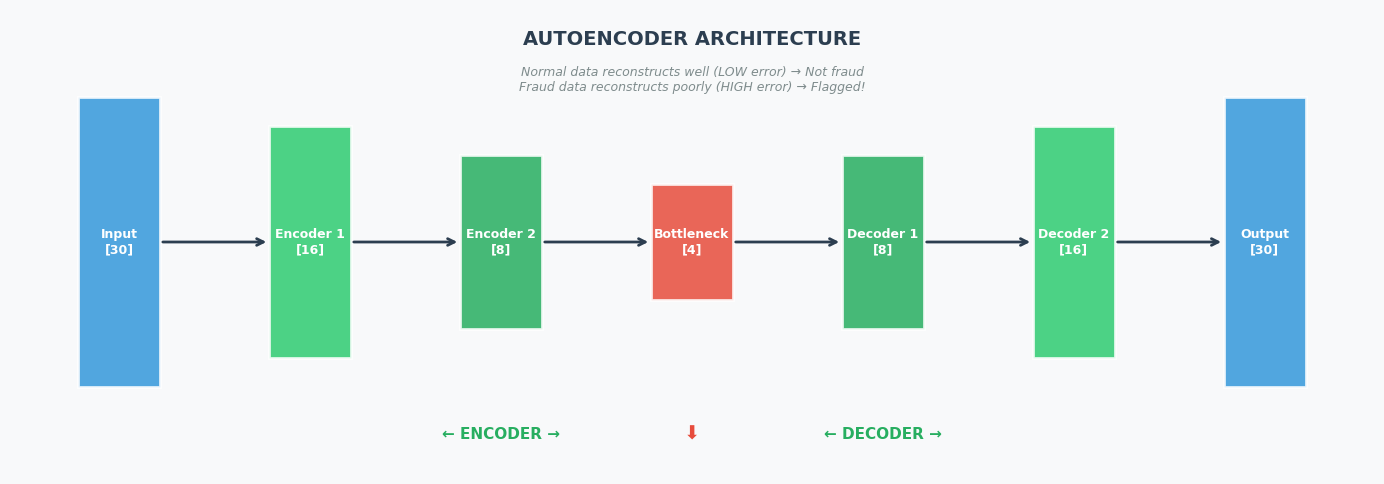

In [35]:
# ============================================================
# CELL 30: Visualise the architecture as a diagram
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# Layer definitions: (x_position, label, size, color)
layers_info = [
    (0.8,  'Input\n[30]',       2.5, '#3498db'),
    (2.2,  'Encoder 1\n[16]',   2.0, '#2ecc71'),
    (3.6,  'Encoder 2\n[8]',    1.5, '#27ae60'),
    (5.0,  'Bottleneck\n[4]',   1.0, '#e74c3c'),
    (6.4,  'Decoder 1\n[8]',    1.5, '#27ae60'),
    (7.8,  'Decoder 2\n[16]',   2.0, '#2ecc71'),
    (9.2,  'Output\n[30]',      2.5, '#3498db'),
]

# Draw layers
for x, label, height, color in layers_info:
    rect = plt.Rectangle((x - 0.3, 2 - height/2), 0.6, height,
                          facecolor=color, edgecolor='white',
                          linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 2, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Draw arrows
for i in range(len(layers_info) - 1):
    x1 = layers_info[i][0] + 0.3
    x2 = layers_info[i+1][0] - 0.3
    ax.annotate('', xy=(x2, 2), xytext=(x1, 2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50',
                               lw=2))

# Labels
ax.text(3.6, 0.3, '← ENCODER →', ha='center', fontsize=11,
        color='#27ae60', fontweight='bold')
ax.text(5.0, 0.3, '⬇', ha='center', fontsize=14, color='#e74c3c')
ax.text(6.4, 0.3, '← DECODER →', ha='center', fontsize=11,
        color='#27ae60', fontweight='bold')
ax.text(5.0, 3.7, 'AUTOENCODER ARCHITECTURE',
        ha='center', fontsize=14, fontweight='bold', color='#2c3e50')
ax.text(5.0, 3.3,
        'Normal data reconstructs well (LOW error) → Not fraud\n'
        'Fraud data reconstructs poorly (HIGH error) → Flagged!',
        ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout()
plt.savefig('autoencoder_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# ============================================================
# CELL 31: Train the Autoencoder
#
# KEY: We train ONLY on normal transactions
# The model learns to reconstruct normal data perfectly
# It will fail to reconstruct fraud → high error = detected!
#
# Callbacks explained:
#   EarlyStopping    → stops if val_loss stops improving (saves time)
#   ReduceLROnPlateau→ lowers learning rate when stuck (helps convergence)
#   ModelCheckpoint  → saves the best version automatically
# ============================================================

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,            # Stop if no improvement for 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # Halve the learning rate when stuck
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_autoencoder.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("🤖 Training Autoencoder on normal transactions only...")
print("   Watch val_loss — it should decrease steadily\n")

start_time = time.time()

history = autoencoder.fit(
    X_train_np, X_train_np,     # Input = Output (that's the autoencoder trick!)
    epochs=100,                  # Max epochs (EarlyStopping will likely stop sooner)
    batch_size=256,
    validation_split=0.1,        # 10% of training data for validation
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

elapsed = time.time() - start_time
print(f"\n✅ Training complete in {elapsed:.1f} seconds!")
print(f"   Stopped at epoch : {len(history.history['loss'])}")
print(f"   Best val_loss    : {min(history.history['val_loss']):.6f}")

🤖 Training Autoencoder on normal transactions only...
   Watch val_loss — it should decrease steadily

Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 1.0547 - mae: 0.6259 - val_loss: 0.7652 - val_mae: 0.5613 - learning_rate: 0.0010
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.8210 - mae: 0.5616 - val_loss: 0.7027 - val_mae: 0.5320 - learning_rate: 0.0010
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7509 - mae: 0.5371 - val_loss: 0.6435 - val_mae: 0.5139 - learning_rate: 0.0010
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7121 - mae: 0.5246 - val_loss: 0.6090 - val_mae: 0.5019 - learning_rate: 0.0010
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.6913 - mae: 0.5194 - val_loss: 0.5952 - val_mae: 0.4982 - learning_rate: 0.0010
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6729 - mae: 0.5154 - val_loss: 0.5814 - val_mae: 0.4909 - learning_rate: 0.0010
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━

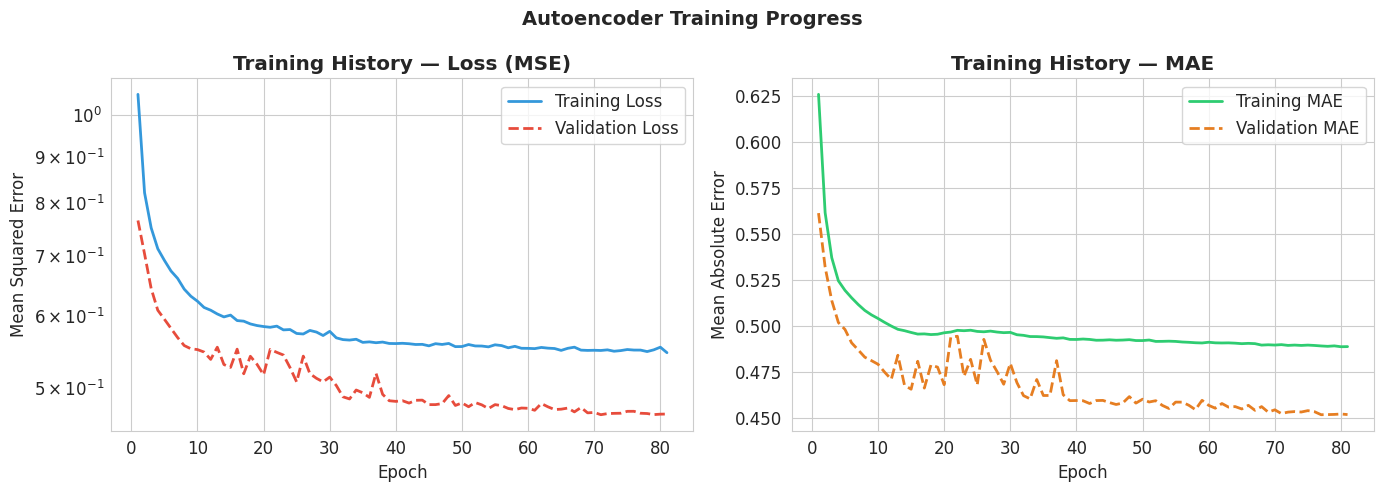

💡 What healthy curves look like:
   ✅ Both lines decrease steadily
   ✅ Training and validation lines stay close
   ❌ Big gap between lines = overfitting
   ❌ Lines not decreasing = learning rate too high


In [37]:
# ============================================================
# CELL 32: Plot training history
# A healthy training curve shows both lines decreasing
# and staying close together (no overfitting)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

# Loss curve
axes[0].plot(epochs_ran, history.history['loss'],
             color='#3498db', lw=2, label='Training Loss')
axes[0].plot(epochs_ran, history.history['val_loss'],
             color='#e74c3c', lw=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Training History — Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].set_yscale('log')   # Log scale shows early improvements better

# MAE curve
axes[1].plot(epochs_ran, history.history['mae'],
             color='#2ecc71', lw=2, label='Training MAE')
axes[1].plot(epochs_ran, history.history['val_mae'],
             color='#e67e22', lw=2, linestyle='--', label='Validation MAE')
axes[1].set_title('Training History — MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()

plt.suptitle('Autoencoder Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 What healthy curves look like:")
print("   ✅ Both lines decrease steadily")
print("   ✅ Training and validation lines stay close")
print("   ❌ Big gap between lines = overfitting")
print("   ❌ Lines not decreasing = learning rate too high")

In [38]:
# ============================================================
# CELL 33: Calculate reconstruction errors
# This is where the magic happens —
# high error = the model couldn't reconstruct it = likely fraud
# ============================================================

# Reconstruct the test set
X_test_reconstructed = autoencoder.predict(X_test_np, verbose=0)

# Calculate reconstruction error per transaction
# MSE per row = mean of squared differences across all 30 features
reconstruction_errors = np.mean(
    np.power(X_test_np - X_test_reconstructed, 2),
    axis=1
)

print(f"Reconstruction Error Statistics:")
print(f"  Overall  — mean: {reconstruction_errors.mean():.6f}, "
      f"std: {reconstruction_errors.std():.6f}")
print(f"  Normal   — mean: "
      f"{reconstruction_errors[y_test_np==0].mean():.6f}")
print(f"  Fraud    — mean: "
      f"{reconstruction_errors[y_test_np==1].mean():.6f}")

ratio = (reconstruction_errors[y_test_np==1].mean() /
         reconstruction_errors[y_test_np==0].mean())
print(f"\n💡 Fraud error is {ratio:.1f}x higher than normal error!")
print(f"   This separation is what allows detection.")

Reconstruction Error Statistics:
  Overall  — mean: 0.624077, std: 4.186182
  Normal   — mean: 0.462763
  Fraud    — mean: 19.268066

💡 Fraud error is 41.6x higher than normal error!
   This separation is what allows detection.


Optimal threshold : 6.624415
At this threshold :
  F1 Score  : 0.6130
  Precision : 0.6816
  Recall    : 0.5569


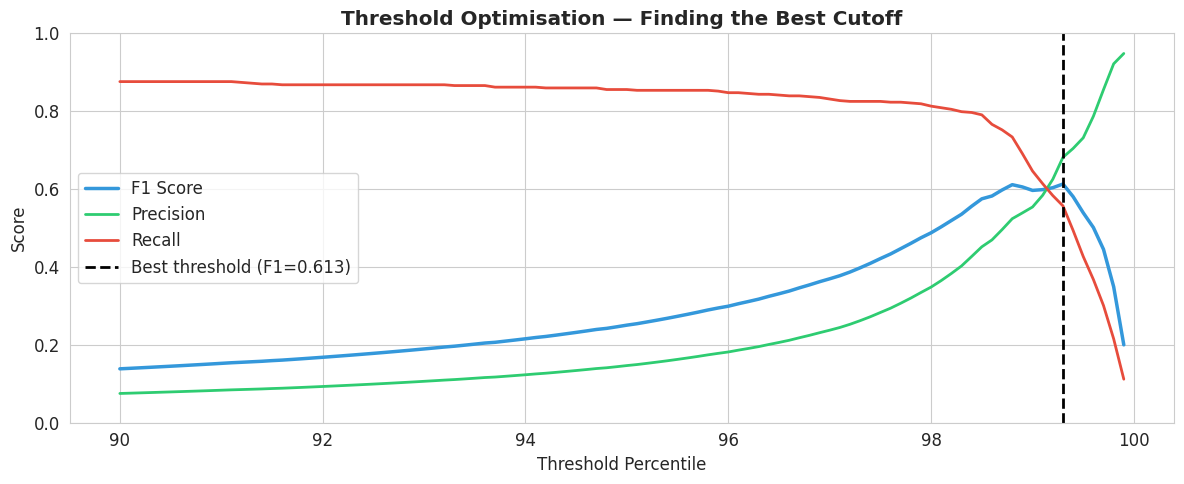

In [39]:
# ============================================================
# CELL 34: Find the optimal threshold
#
# We need to decide: "above what error level do we flag fraud?"
# Too low  → too many false alarms (annoying customers)
# Too high → miss real fraud (costly)
#
# We find the threshold that maximises F1 score
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score

# Test many possible thresholds
thresholds   = np.percentile(reconstruction_errors, np.arange(90, 100, 0.1))
f1_scores    = []
precisions   = []
recalls      = []

for threshold in thresholds:
    preds = (reconstruction_errors > threshold).astype(int)
    f1_scores.append(f1_score(y_test_np, preds, zero_division=0))
    precisions.append(precision_score(y_test_np, preds, zero_division=0))
    recalls.append(recall_score(y_test_np, preds, zero_division=0))

# Best threshold = highest F1
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold : {best_threshold:.6f}")
print(f"At this threshold :")
print(f"  F1 Score  : {best_f1:.4f}")
print(f"  Precision : {precisions[best_idx]:.4f}")
print(f"  Recall    : {recalls[best_idx]:.4f}")

# Plot threshold analysis
fig, ax = plt.subplots(figsize=(12, 5))
percentiles = np.arange(90, 100, 0.1)
ax.plot(percentiles, f1_scores,    color='#3498db', lw=2.5, label='F1 Score')
ax.plot(percentiles, precisions,   color='#2ecc71', lw=2, label='Precision')
ax.plot(percentiles, recalls,      color='#e74c3c', lw=2, label='Recall')
ax.axvline(x=percentiles[best_idx], color='black',
           linestyle='--', lw=2, label=f'Best threshold (F1={best_f1:.3f})')
ax.set_xlabel('Threshold Percentile')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation — Finding the Best Cutoff',
             fontweight='bold')
ax.legend()
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ============================================================
# CELL 35: Final Autoencoder evaluation
# ============================================================

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)

# Apply best threshold for binary predictions
ae_labels = (reconstruction_errors > best_threshold).astype(int)
ae_scores  = reconstruction_errors   # Higher = more anomalous

ae_auc_roc = roc_auc_score(y_test_np, ae_scores)
ae_auc_pr  = average_precision_score(y_test_np, ae_scores)

print("=" * 55)
print("      AUTOENCODER — EVALUATION RESULTS")
print("=" * 55)
print(f"\n  AUC-ROC Score : {ae_auc_roc:.4f}")
print(f"  AUC-PR Score  : {ae_auc_pr:.4f}")
print(f"  Best F1 Score : {best_f1:.4f}")
print(f"\n--- Classification Report ---")
print(classification_report(y_test_np, ae_labels,
                             target_names=['Normal', 'Fraud']))

      AUTOENCODER — EVALUATION RESULTS

  AUC-ROC Score : 0.9536
  AUC-PR Score  : 0.6156
  Best F1 Score : 0.6130

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       0.68      0.56      0.61       492

    accuracy                           0.99     57355
   macro avg       0.84      0.78      0.80     57355
weighted avg       0.99      0.99      0.99     57355



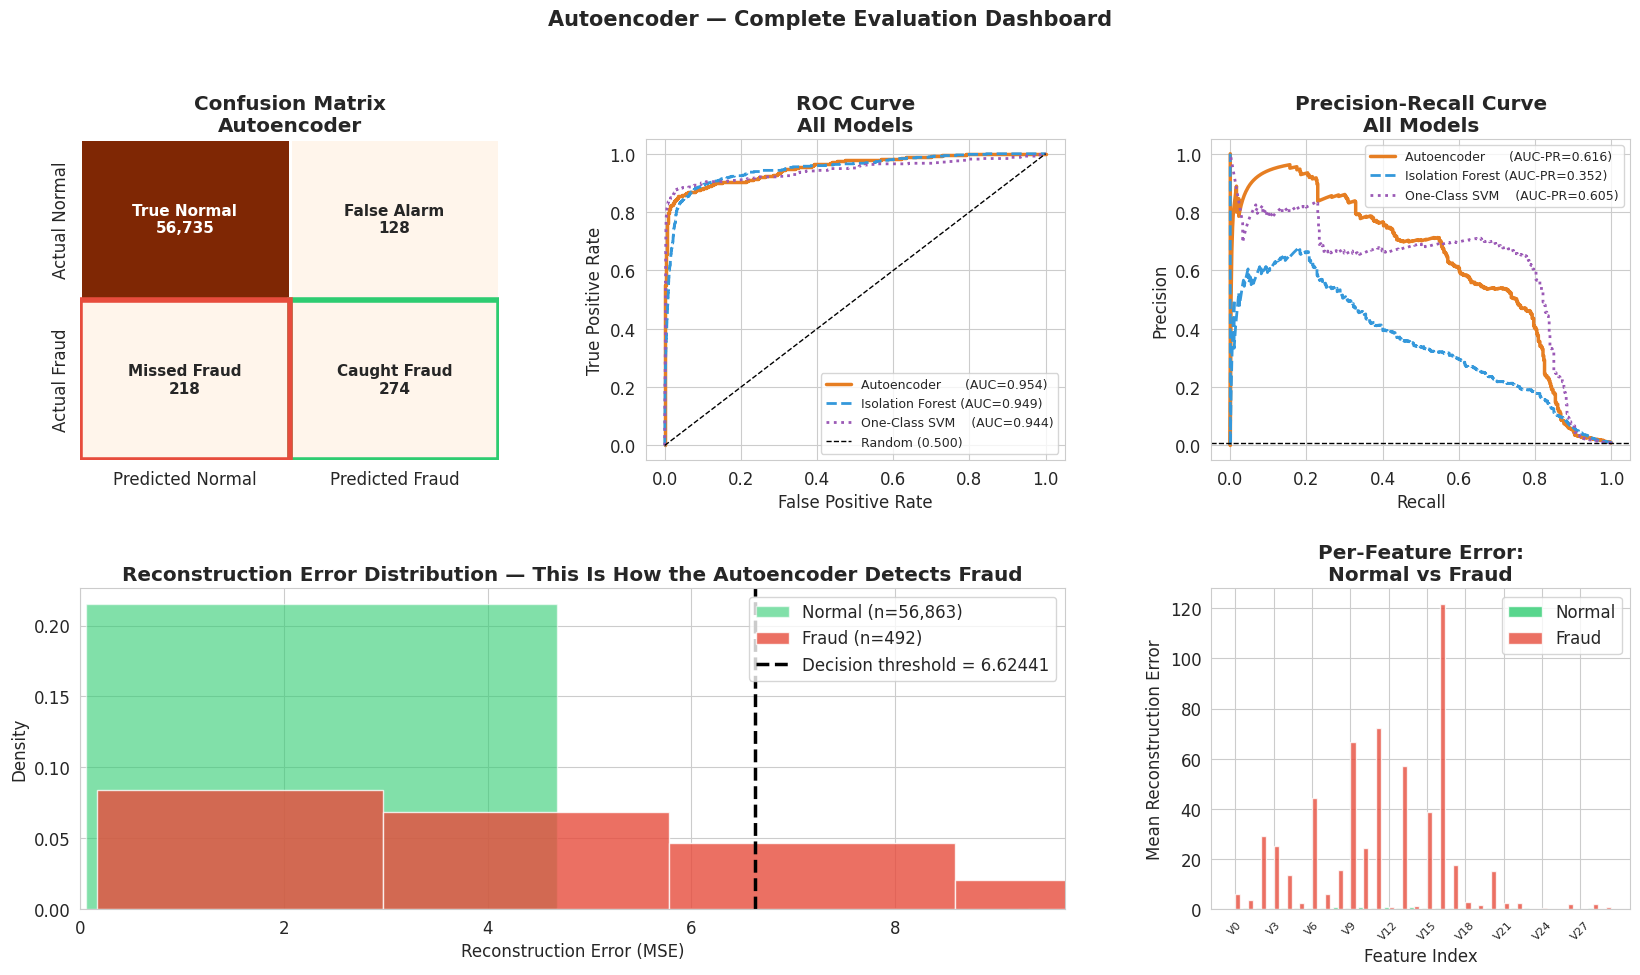

In [41]:
# ============================================================
# CELL 36: Full visualisation — Confusion matrix + curves
#          + reconstruction error distribution
# ============================================================

fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# --- 1. Confusion Matrix ---
ax1 = fig.add_subplot(gs[0, 0])
cm_ae = confusion_matrix(y_test_np, ae_labels)
labels_cm = np.array([
    [f"True Normal\n{cm_ae[0,0]:,}", f"False Alarm\n{cm_ae[0,1]:,}"],
    [f"Missed Fraud\n{cm_ae[1,0]:,}", f"Caught Fraud\n{cm_ae[1,1]:,}"]
])
sns.heatmap(cm_ae, annot=labels_cm, fmt='', cmap='Oranges',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            ax=ax1, linewidths=2, linecolor='white',
            cbar=False, annot_kws={"size": 11, "weight": "bold"})
ax1.set_title('Confusion Matrix\nAutoencoder', fontweight='bold')
ax1.add_patch(plt.Rectangle((1,1), 1, 1, fill=False,
                              edgecolor='#2ecc71', lw=4))
ax1.add_patch(plt.Rectangle((0,1), 1, 1, fill=False,
                              edgecolor='#e74c3c', lw=4))

# --- 2. ROC Curve (all 3 models) ---
ax2 = fig.add_subplot(gs[0, 1])
fpr_ae, tpr_ae, _ = roc_curve(y_test_np, ae_scores)
ax2.plot(fpr_ae,  tpr_ae,  color='#e67e22', lw=2.5,
         label=f'Autoencoder      (AUC={ae_auc_roc:.3f})')
ax2.plot(fpr_if,  tpr_if,  color='#3498db', lw=2, linestyle='--',
         label=f'Isolation Forest (AUC={results["Isolation Forest"]["auc_roc"]:.3f})')
ax2.plot(fpr_svm, tpr_svm, color='#9b59b6', lw=2, linestyle=':',
         label=f'One-Class SVM    (AUC={results["One-Class SVM"]["auc_roc"]:.3f})')
ax2.plot([0,1],[0,1],'k--', lw=1, label='Random (0.500)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve\nAll Models', fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')

# --- 3. Precision-Recall Curve (all 3 models) ---
ax3 = fig.add_subplot(gs[0, 2])
prec_ae, rec_ae, _ = precision_recall_curve(y_test_np, ae_scores)
ax3.plot(rec_ae,  prec_ae,  color='#e67e22', lw=2.5,
         label=f'Autoencoder      (AUC-PR={ae_auc_pr:.3f})')
ax3.plot(rec_if,  prec_if,  color='#3498db', lw=2, linestyle='--',
         label=f'Isolation Forest (AUC-PR={results["Isolation Forest"]["auc_pr"]:.3f})')
ax3.plot(rec_svm, prec_svm, color='#9b59b6', lw=2, linestyle=':',
         label=f'One-Class SVM    (AUC-PR={results["One-Class SVM"]["auc_pr"]:.3f})')
ax3.axhline(y=y_test.mean(), color='k', linestyle='--', lw=1)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve\nAll Models', fontweight='bold')
ax3.legend(fontsize=9)

# --- 4. Reconstruction Error Distribution ---
ax4 = fig.add_subplot(gs[1, :2])
normal_errors = reconstruction_errors[y_test_np == 0]
fraud_errors  = reconstruction_errors[y_test_np == 1]

ax4.hist(normal_errors, bins=150, alpha=0.6, color='#2ecc71',
         label=f'Normal (n={len(normal_errors):,})', density=True)
ax4.hist(fraud_errors,  bins=50,  alpha=0.8, color='#e74c3c',
         label=f'Fraud (n={len(fraud_errors):,})',  density=True)
ax4.axvline(best_threshold, color='black', linestyle='--', lw=2.5,
            label=f'Decision threshold = {best_threshold:.5f}')
ax4.set_xlabel('Reconstruction Error (MSE)')
ax4.set_ylabel('Density')
ax4.set_title('Reconstruction Error Distribution — '
              'This Is How the Autoencoder Detects Fraud',
              fontweight='bold')
ax4.legend()
ax4.set_xlim([0, np.percentile(reconstruction_errors, 99.5)])

# --- 5. Per-feature reconstruction error ---
ax5 = fig.add_subplot(gs[1, 2])
feature_errors_normal = np.mean(
    np.power(X_test_np[y_test_np==0] -
             X_test_reconstructed[y_test_np==0], 2), axis=0)
feature_errors_fraud  = np.mean(
    np.power(X_test_np[y_test_np==1] -
             X_test_reconstructed[y_test_np==1], 2), axis=0)

x_pos = np.arange(len(feature_errors_normal))
ax5.bar(x_pos - 0.2, feature_errors_normal, 0.4,
        label='Normal', color='#2ecc71', alpha=0.8)
ax5.bar(x_pos + 0.2, feature_errors_fraud,  0.4,
        label='Fraud',  color='#e74c3c', alpha=0.8)
ax5.set_xlabel('Feature Index')
ax5.set_ylabel('Mean Reconstruction Error')
ax5.set_title('Per-Feature Error:\nNormal vs Fraud', fontweight='bold')
ax5.legend()
ax5.set_xticks(x_pos[::3])
ax5.set_xticklabels([f'V{i}' for i in range(0, len(x_pos), 3)],
                     rotation=45, fontsize=8)

plt.suptitle('Autoencoder — Complete Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('autoencoder_full_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# ============================================================
# CELL 37: Save Autoencoder results + update leaderboard
# ============================================================

autoencoder.save('autoencoder_model.keras')

results['Autoencoder'] = {
    'auc_roc'  : round(ae_auc_roc, 4),
    'auc_pr'   : round(ae_auc_pr, 4),
    'precision': round(precisions[best_idx], 4),
    'recall'   : round(recalls[best_idx], 4),
    'caught'   : int(cm_ae[1,1]),
    'missed'   : int(cm_ae[1,0]),
}

# Store scores for later comparison steps
ae_scores_saved  = reconstruction_errors
with open('model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
np.save('ae_scores.npy', ae_scores_saved)

print("✅ Model and results saved!\n")
print("=" * 58)
print("          📊 UPDATED LEADERBOARD")
print("=" * 58)
print(f"  {'Model':<22} {'AUC-ROC':>8} {'AUC-PR':>8} {'Caught':>8}")
print(f"  {'-'*54}")
for model, r in results.items():
    marker = ' 🏆' if model == max(results,
                     key=lambda m: results[m]['auc_roc']) else ''
    print(f"  {model:<22} {r['auc_roc']:>8.4f} "
          f"{r['auc_pr']:>8.4f} {r['caught']:>5}/492{marker}")
print(f"  {'-'*54}")
print(f"  {'Random Baseline':<22} {'0.5000':>8} {'0.0086':>8}")
print("=" * 58)

✅ Model and results saved!

          📊 UPDATED LEADERBOARD
  Model                   AUC-ROC   AUC-PR   Caught
  ------------------------------------------------------
  Isolation Forest         0.9494   0.3516   116/492
  One-Class SVM            0.9442   0.6054   432/492
  Autoencoder              0.9536   0.6156   274/492 🏆
  ------------------------------------------------------
  Random Baseline          0.5000   0.0086


In [43]:
# ============================================================
# CELL 38: Define the hyperparameter search space
#
# We'll test different combinations of:
#   - Layer sizes (how wide the network is)
#   - Bottleneck size (how much compression)
#   - Learning rate (how fast the network learns)
#   - Dropout rate (how much regularisation)
#   - Batch size (how many samples per update)
# ============================================================

import itertools
import random
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.metrics import precision_score, recall_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the search space
param_grid = {
    'encoding_dim_1' : [32, 16],        # First encoder layer size
    'encoding_dim_2' : [16, 8],         # Second encoder layer size
    'bottleneck'     : [8, 4, 2],       # Bottleneck size
    'learning_rate'  : [0.001, 0.0005], # Adam learning rate
    'dropout_rate'   : [0.1, 0.2],      # Dropout regularisation
    'batch_size'     : [128, 256],      # Samples per gradient update
}

# Calculate total combinations
total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)

print(f"Total possible combinations : {total_combinations}")
print(f"We will randomly sample     : 10 combinations")
print(f"This saves ~{total_combinations - 10}x time vs full grid search\n")

# Randomly sample 10 unique combinations
random.seed(42)
all_combos = list(itertools.product(*param_grid.values()))
sampled_combos = random.sample(all_combos, min(10, len(all_combos)))

param_keys = list(param_grid.keys())
print("🎲 Sampled hyperparameter combinations:")
print(f"  {'#':<4} {'enc1':<6} {'enc2':<6} {'btl':<5} "
      f"{'lr':<8} {'drop':<6} {'batch':<6}")
print(f"  {'-'*45}")
for i, combo in enumerate(sampled_combos):
    print(f"  {i+1:<4} {combo[0]:<6} {combo[1]:<6} {combo[2]:<5} "
          f"{combo[3]:<8} {combo[4]:<6} {combo[5]:<6}")

Total possible combinations : 96
We will randomly sample     : 10 combinations
This saves ~86x time vs full grid search

🎲 Sampled hyperparameter combinations:
  #    enc1   enc2   btl   lr       drop   batch 
  ---------------------------------------------
  1    16     8      4     0.001    0.1    256   
  2    32     16     4     0.0005   0.2    128   
  3    32     16     8     0.001    0.2    256   
  4    16     8      2     0.0005   0.2    128   
  5    32     8      4     0.001    0.2    256   
  6    32     8      8     0.0005   0.2    256   
  7    32     8      8     0.0005   0.1    128   
  8    32     16     2     0.001    0.1    256   
  9    32     16     4     0.0005   0.1    256   
  10   16     8      4     0.0005   0.2    128   


In [44]:
# ============================================================
# CELL 39: Build a flexible autoencoder function
#          (same architecture as before, but configurable)
# ============================================================

def build_flexible_autoencoder(input_dim, enc1, enc2,
                                bottleneck, dropout_rate, learning_rate):
    """Builds an autoencoder with configurable hyperparameters."""

    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(enc1, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(enc2, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Bottleneck
    encoded = layers.Dense(bottleneck, activation='relu')(x)

    # Decoder (mirror of encoder)
    x = layers.Dense(enc2, activation='relu')(encoded)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(enc1, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Output
    outputs = layers.Dense(input_dim, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model


def evaluate_autoencoder(model, X_test_np, y_test_np, threshold_percentile=95):
    """Evaluates a trained autoencoder and returns key metrics."""
    reconstructed = model.predict(X_test_np, verbose=0)
    errors = np.mean(np.power(X_test_np - reconstructed, 2), axis=1)
    threshold = np.percentile(errors, threshold_percentile)
    preds = (errors > threshold).astype(int)

    return {
        'auc_roc'  : roc_auc_score(y_test_np, errors),
        'auc_pr'   : average_precision_score(y_test_np, errors),
        'f1'       : f1_score(y_test_np, preds, zero_division=0),
        'precision': precision_score(y_test_np, preds, zero_division=0),
        'recall'   : recall_score(y_test_np, preds, zero_division=0),
        'errors'   : errors
    }

print("✅ Flexible autoencoder builder ready!")

✅ Flexible autoencoder builder ready!


In [45]:
# ============================================================
# CELL 40: Run the hyperparameter search
#
# For each combination:
#   1. Build a fresh autoencoder
#   2. Train it (with early stopping to save time)
#   3. Evaluate on test set
#   4. Record results
#
# ⏱️ Expected time: 5–15 minutes total
# ============================================================

tuning_results = []

callbacks_tuning = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=0)
]

print("🔍 Starting hyperparameter search...")
print("=" * 70)

for i, combo in enumerate(sampled_combos):
    params = dict(zip(param_keys, combo))

    print(f"\n[{i+1:2d}/10] Testing: enc1={params['encoding_dim_1']}, "
          f"enc2={params['encoding_dim_2']}, "
          f"bottleneck={params['bottleneck']}, "
          f"lr={params['learning_rate']}, "
          f"dropout={params['dropout_rate']}, "
          f"batch={params['batch_size']}")

    # Skip invalid combinations (enc2 must be < enc1, bottleneck < enc2)
    if (params['encoding_dim_2'] >= params['encoding_dim_1'] or
            params['bottleneck'] >= params['encoding_dim_2']):
        print(f"       ⏭️  Skipped — invalid architecture shape")
        continue

    start = time.time()

    # Build fresh model
    model = build_flexible_autoencoder(
        input_dim     = X_train_np.shape[1],
        enc1          = params['encoding_dim_1'],
        enc2          = params['encoding_dim_2'],
        bottleneck    = params['bottleneck'],
        dropout_rate  = params['dropout_rate'],
        learning_rate = params['learning_rate']
    )

    # Train
    model.fit(
        X_train_np, X_train_np,
        epochs          = 60,
        batch_size      = params['batch_size'],
        validation_split= 0.1,
        callbacks       = callbacks_tuning,
        verbose         = 0
    )

    # Evaluate
    metrics = evaluate_autoencoder(model, X_test_np, y_test_np)
    elapsed = time.time() - start

    result = {**params,
              'auc_roc'  : metrics['auc_roc'],
              'auc_pr'   : metrics['auc_pr'],
              'f1'       : metrics['f1'],
              'precision': metrics['precision'],
              'recall'   : metrics['recall'],
              'time_sec' : round(elapsed, 1)}

    tuning_results.append(result)

    print(f"       ✅ AUC-ROC={metrics['auc_roc']:.4f} | "
          f"AUC-PR={metrics['auc_pr']:.4f} | "
          f"F1={metrics['f1']:.4f} | "
          f"Time={elapsed:.0f}s")

    # Clear session to free GPU memory between runs
    keras.backend.clear_session()
    tf.random.set_seed(42)

print("\n✅ Hyperparameter search complete!")

🔍 Starting hyperparameter search...

[ 1/10] Testing: enc1=16, enc2=8, bottleneck=4, lr=0.001, dropout=0.1, batch=256
       ✅ AUC-ROC=0.9539 | AUC-PR=0.6390 | F1=0.2500 | Time=149s

[ 2/10] Testing: enc1=32, enc2=16, bottleneck=4, lr=0.0005, dropout=0.2, batch=128
       ✅ AUC-ROC=0.9561 | AUC-PR=0.5535 | F1=0.2560 | Time=44s

[ 3/10] Testing: enc1=32, enc2=16, bottleneck=8, lr=0.001, dropout=0.2, batch=256
       ✅ AUC-ROC=0.9544 | AUC-PR=0.7031 | F1=0.2506 | Time=219s

[ 4/10] Testing: enc1=16, enc2=8, bottleneck=2, lr=0.0005, dropout=0.2, batch=128
       ✅ AUC-ROC=0.9548 | AUC-PR=0.4896 | F1=0.2565 | Time=48s

[ 5/10] Testing: enc1=32, enc2=8, bottleneck=4, lr=0.001, dropout=0.2, batch=256
       ✅ AUC-ROC=0.9614 | AUC-PR=0.5733 | F1=0.2583 | Time=28s

[ 6/10] Testing: enc1=32, enc2=8, bottleneck=8, lr=0.0005, dropout=0.2, batch=256
       ⏭️  Skipped — invalid architecture shape

[ 7/10] Testing: enc1=32, enc2=8, bottleneck=8, lr=0.0005, dropout=0.1, batch=128
       ⏭️  Skipped 

In [46]:
# ============================================================
# CELL 41: Analyse tuning results
# ============================================================

tuning_df = pd.DataFrame(tuning_results).sort_values(
    'auc_roc', ascending=False
).reset_index(drop=True)

print("=" * 75)
print("           HYPERPARAMETER TUNING RESULTS (sorted by AUC-ROC)")
print("=" * 75)
print(tuning_df[['encoding_dim_1', 'encoding_dim_2', 'bottleneck',
                  'learning_rate', 'dropout_rate', 'batch_size',
                  'auc_roc', 'auc_pr', 'f1']].to_string(index=True))

print(f"\n🏆 Best configuration:")
best = tuning_df.iloc[0]
print(f"   Architecture  : {int(best['encoding_dim_1'])} → "
      f"{int(best['encoding_dim_2'])} → "
      f"{int(best['bottleneck'])} → "
      f"{int(best['encoding_dim_2'])} → "
      f"{int(best['encoding_dim_1'])}")
print(f"   Learning rate : {best['learning_rate']}")
print(f"   Dropout rate  : {best['dropout_rate']}")
print(f"   Batch size    : {int(best['batch_size'])}")
print(f"   AUC-ROC       : {best['auc_roc']:.4f}")
print(f"   AUC-PR        : {best['auc_pr']:.4f}")
print(f"   F1 Score      : {best['f1']:.4f}")

           HYPERPARAMETER TUNING RESULTS (sorted by AUC-ROC)
   encoding_dim_1  encoding_dim_2  bottleneck  learning_rate  dropout_rate  batch_size   auc_roc    auc_pr        f1
0              32               8           4         0.0010           0.2         256  0.961408  0.573313  0.258333
1              32              16           2         0.0010           0.1         256  0.957170  0.425702  0.257143
2              32              16           4         0.0005           0.2         128  0.956148  0.553539  0.255952
3              16               8           2         0.0005           0.2         128  0.954806  0.489597  0.256548
4              16               8           4         0.0005           0.2         128  0.954538  0.436580  0.255952
5              32              16           8         0.0010           0.2         256  0.954378  0.703101  0.250595
6              16               8           4         0.0010           0.1         256  0.953898  0.639031  0.250000
7  

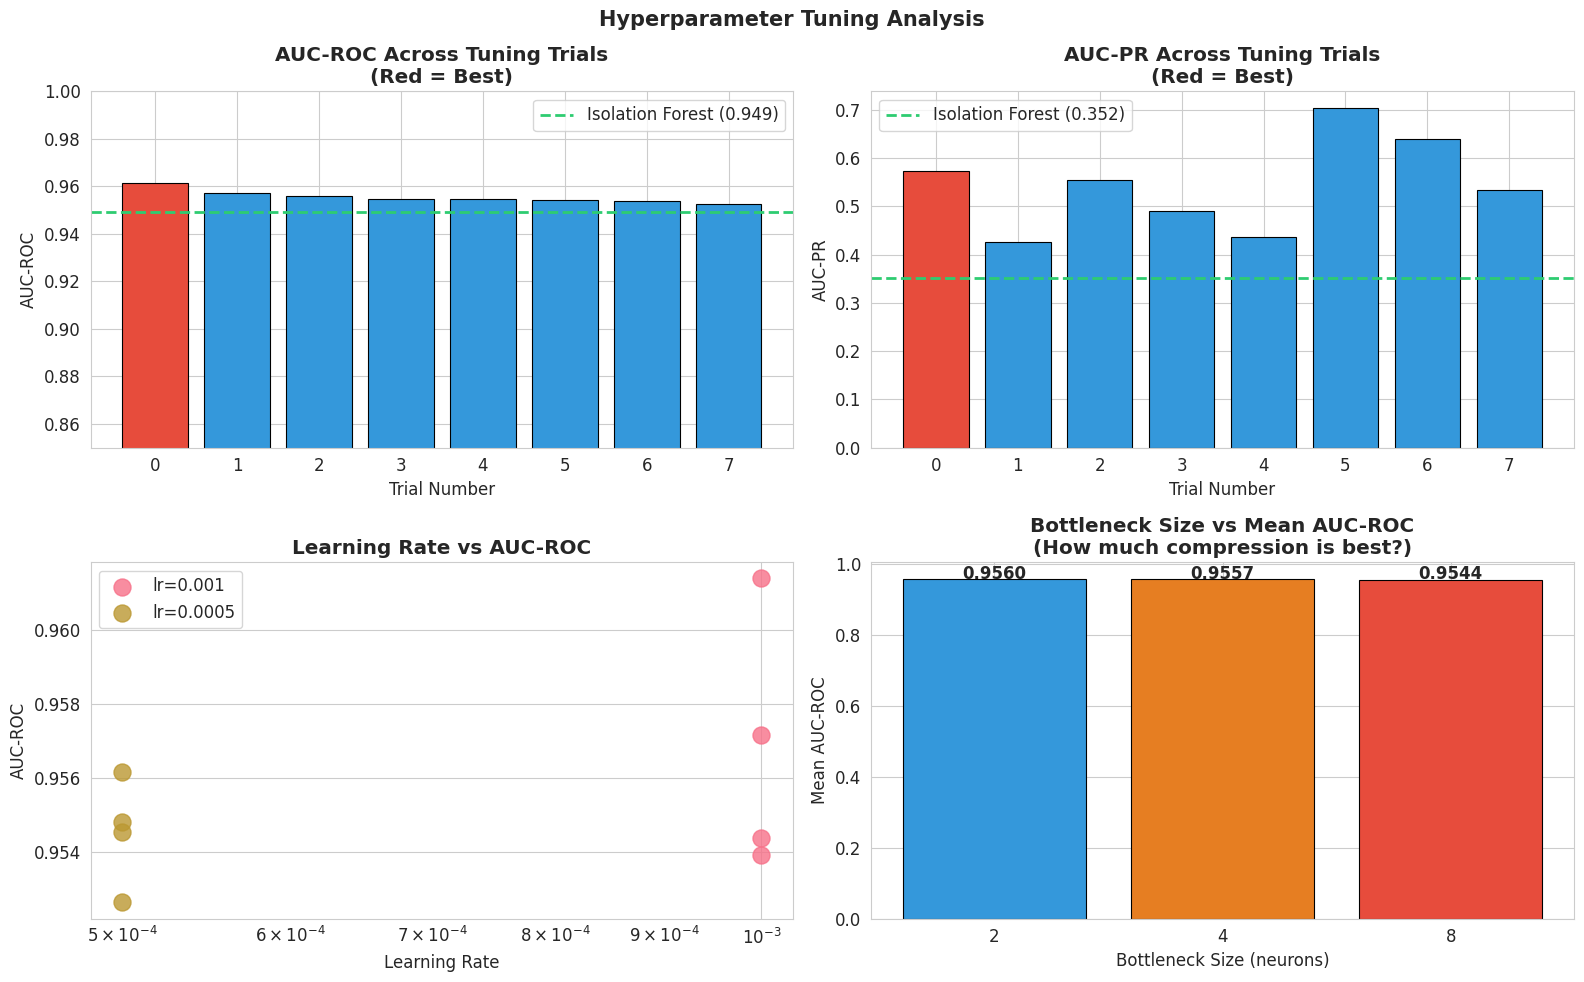

In [47]:
# ============================================================
# CELL 42: Visualise the tuning results
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. AUC-ROC across all trials ---
colors = ['#e74c3c' if i == 0 else '#3498db'
          for i in range(len(tuning_df))]
axes[0, 0].bar(range(len(tuning_df)), tuning_df['auc_roc'],
               color=colors, edgecolor='black', linewidth=0.8)
axes[0, 0].axhline(y=results['Isolation Forest']['auc_roc'],
                   color='#2ecc71', linestyle='--', lw=2,
                   label=f"Isolation Forest ({results['Isolation Forest']['auc_roc']:.3f})")
axes[0, 0].set_xlabel('Trial Number')
axes[0, 0].set_ylabel('AUC-ROC')
axes[0, 0].set_title('AUC-ROC Across Tuning Trials\n(Red = Best)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_ylim([0.85, 1.0])

# --- 2. AUC-PR across all trials ---
axes[0, 1].bar(range(len(tuning_df)), tuning_df['auc_pr'],
               color=colors, edgecolor='black', linewidth=0.8)
axes[0, 1].axhline(y=results['Isolation Forest']['auc_pr'],
                   color='#2ecc71', linestyle='--', lw=2,
                   label=f"Isolation Forest ({results['Isolation Forest']['auc_pr']:.3f})")
axes[0, 1].set_xlabel('Trial Number')
axes[0, 1].set_ylabel('AUC-PR')
axes[0, 1].set_title('AUC-PR Across Tuning Trials\n(Red = Best)', fontweight='bold')
axes[0, 1].legend()

# --- 3. Learning rate impact ---
for lr in tuning_df['learning_rate'].unique():
    subset = tuning_df[tuning_df['learning_rate'] == lr]
    axes[1, 0].scatter(subset['learning_rate'],
                       subset['auc_roc'],
                       s=150, alpha=0.8, label=f'lr={lr}',
                       zorder=5)
axes[1, 0].set_xlabel('Learning Rate')
axes[1, 0].set_ylabel('AUC-ROC')
axes[1, 0].set_title('Learning Rate vs AUC-ROC', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xscale('log')

# --- 4. Bottleneck size impact ---
bottleneck_perf = tuning_df.groupby('bottleneck')['auc_roc'].mean()
axes[1, 1].bar(bottleneck_perf.index.astype(str),
               bottleneck_perf.values,
               color=['#3498db', '#e67e22', '#e74c3c'],
               edgecolor='black', linewidth=0.8)
axes[1, 1].set_xlabel('Bottleneck Size (neurons)')
axes[1, 1].set_ylabel('Mean AUC-ROC')
axes[1, 1].set_title('Bottleneck Size vs Mean AUC-ROC\n'
                     '(How much compression is best?)',
                     fontweight='bold')
for i, (idx, val) in enumerate(bottleneck_perf.items()):
    axes[1, 1].text(i, val + 0.001, f'{val:.4f}',
                    ha='center', fontweight='bold')

plt.suptitle('Hyperparameter Tuning Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# ============================================================
# CELL 43: Retrain the BEST model from scratch with more epochs
#          Now we know the best config, train it properly
# ============================================================

print("🏆 Retraining best configuration with full epochs...\n")

best_params = tuning_df.iloc[0]

best_autoencoder = build_flexible_autoencoder(
    input_dim     = X_train_np.shape[1],
    enc1          = int(best_params['encoding_dim_1']),
    enc2          = int(best_params['encoding_dim_2']),
    bottleneck    = int(best_params['bottleneck']),
    dropout_rate  = best_params['dropout_rate'],
    learning_rate = best_params['learning_rate']
)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_tuned_autoencoder.keras',
        monitor='val_loss',
        save_best_only=True, verbose=0)
]

history_tuned = best_autoencoder.fit(
    X_train_np, X_train_np,
    epochs           = 150,
    batch_size       = int(best_params['batch_size']),
    validation_split = 0.1,
    callbacks        = callbacks_final,
    shuffle          = True,
    verbose          = 1
)

# Evaluate tuned model
tuned_metrics = evaluate_autoencoder(best_autoencoder, X_test_np, y_test_np)

print(f"\n{'='*55}")
print(f"  TUNED AUTOENCODER RESULTS")
print(f"{'='*55}")
print(f"  AUC-ROC : {tuned_metrics['auc_roc']:.4f}  "
      f"(was {results['Autoencoder']['auc_roc']:.4f}  "
      f"Δ {tuned_metrics['auc_roc']-results['Autoencoder']['auc_roc']:+.4f})")
print(f"  AUC-PR  : {tuned_metrics['auc_pr']:.4f}  "
      f"(was {results['Autoencoder']['auc_pr']:.4f}  "
      f"Δ {tuned_metrics['auc_pr']-results['Autoencoder']['auc_pr']:+.4f})")
print(f"  F1      : {tuned_metrics['f1']:.4f}  "
      f"(was {results['Autoencoder']['auc_pr']:.4f})")

🏆 Retraining best configuration with full epochs...

Epoch 1/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.0056 - val_loss: 0.7111 - learning_rate: 0.0010
Epoch 2/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7918 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 3/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.7341 - val_loss: 0.5824 - learning_rate: 0.0010
Epoch 4/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6981 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 5/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6777 - val_loss: 0.5588 - learning_rate: 0.0010
Epoch 6/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6662 - val_loss: 0.5427 - learning_rate: 0.0010
Epoch 7/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6551 - val_loss: 0.5351 - learning_rate: 0.0010
Epoch 8/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6484 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 9/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss

In [49]:
# ============================================================
# CELL 44: Update leaderboard with tuned model
# ============================================================

from sklearn.metrics import confusion_matrix

tuned_errors  = tuned_metrics['errors']
tuned_threshold = np.percentile(tuned_errors, 95)
tuned_labels  = (tuned_errors > tuned_threshold).astype(int)
cm_tuned      = confusion_matrix(y_test_np, tuned_labels)

results['Autoencoder (Tuned)'] = {
    'auc_roc'  : round(tuned_metrics['auc_roc'], 4),
    'auc_pr'   : round(tuned_metrics['auc_pr'],  4),
    'precision': round(tuned_metrics['precision'], 4),
    'recall'   : round(tuned_metrics['recall'],    4),
    'caught'   : int(cm_tuned[1,1]),
    'missed'   : int(cm_tuned[1,0]),
}

with open('model_results.pkl', 'wb') as f:
    pickle.dump(results, f)

np.save('tuned_ae_scores.npy', tuned_errors)
best_autoencoder.save('best_tuned_autoencoder.keras')

print("=" * 58)
print("          📊 FINAL LEADERBOARD")
print("=" * 58)
print(f"  {'Model':<26} {'AUC-ROC':>8} {'AUC-PR':>8} {'Caught':>8}")
print(f"  {'-'*56}")
for model, r in results.items():
    is_best = r['auc_roc'] == max(v['auc_roc'] for v in results.values())
    marker  = ' 🏆' if is_best else ''
    print(f"  {model:<26} {r['auc_roc']:>8.4f} "
          f"{r['auc_pr']:>8.4f} {r['caught']:>5}/492{marker}")
print(f"  {'-'*56}")
print(f"  {'Random Baseline':<26} {'0.5000':>8} {'0.0086':>8}")
print("=" * 58)
print("\n✅ All results saved!")

          📊 FINAL LEADERBOARD
  Model                       AUC-ROC   AUC-PR   Caught
  --------------------------------------------------------
  Isolation Forest             0.9494   0.3516   116/492
  One-Class SVM                0.9442   0.6054   432/492
  Autoencoder                  0.9536   0.6156   274/492
  Autoencoder (Tuned)          0.9579   0.6507   421/492 🏆
  --------------------------------------------------------
  Random Baseline              0.5000   0.0086

✅ All results saved!


In [50]:
# ============================================================
# CELL 45: Load all saved results (run if restarting Colab)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# Load saved results
with open('model_results.pkl', 'rb') as f:
    results = pickle.load(f)

# Load anomaly scores for curve plotting
if_scores_flipped   = -np.load('if_scores.npy')   \
                       if False else if_scores_flipped
ae_scores           = np.load('ae_scores.npy')
tuned_ae_scores     = np.load('tuned_ae_scores.npy')

print("✅ All results loaded!")
print(f"\nModels in results: {list(results.keys())}")
print(f"\nQuick peek:")
for model, r in results.items():
    print(f"  {model:<26} AUC-ROC={r['auc_roc']:.4f}  "
          f"Caught={r['caught']}/492")

✅ All results loaded!

Models in results: ['Isolation Forest', 'One-Class SVM', 'Autoencoder', 'Autoencoder (Tuned)']

Quick peek:
  Isolation Forest           AUC-ROC=0.9494  Caught=116/492
  One-Class SVM              AUC-ROC=0.9442  Caught=432/492
  Autoencoder                AUC-ROC=0.9536  Caught=274/492
  Autoencoder (Tuned)        AUC-ROC=0.9579  Caught=421/492


In [51]:
# ============================================================
# CELL 46: Master comparison table — clean and professional
# ============================================================

# Build a rich comparison DataFrame
comparison_data = []
for model, r in results.items():
    total_flagged = r['caught'] + int(
        r['caught'] / r['recall'] * (1 - r['recall'])
    ) if r['recall'] > 0 else 0

    comparison_data.append({
        'Model'          : model,
        'AUC-ROC'        : r['auc_roc'],
        'AUC-PR'         : r['auc_pr'],
        'Precision'      : r['precision'],
        'Recall'         : r['recall'],
        'F1 Score'       : round(2 * r['precision'] * r['recall'] /
                           (r['precision'] + r['recall'] + 1e-9), 4),
        'Fraud Caught'   : f"{r['caught']}/492",
        'Fraud Missed'   : r['missed'],
    })

comp_df = pd.DataFrame(comparison_data).set_index('Model')

print("=" * 85)
print("                    COMPLETE MODEL COMPARISON TABLE")
print("=" * 85)
print(comp_df.to_string())
print("=" * 85)

# Highlight the winner in each column
print("\n🏆 Best model per metric:")
numeric_cols = ['AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1 Score']
for col in numeric_cols:
    best_model = comp_df[col].idxmax()
    best_val   = comp_df[col].max()
    print(f"   {col:<12} → {best_model:<26} ({best_val:.4f})")

                    COMPLETE MODEL COMPARISON TABLE
                     AUC-ROC  AUC-PR  Precision  Recall  F1 Score Fraud Caught  Fraud Missed
Model                                                                                       
Isolation Forest      0.9494  0.3516     0.5659  0.2358    0.3329      116/492           376
One-Class SVM         0.9442  0.6054     0.1890  0.8780    0.3110      432/492            60
Autoencoder           0.9536  0.6156     0.6816  0.5569    0.6130      274/492           218
Autoencoder (Tuned)   0.9579  0.6507     0.1468  0.8557    0.2506      421/492            71

🏆 Best model per metric:
   AUC-ROC      → Autoencoder (Tuned)        (0.9579)
   AUC-PR       → Autoencoder (Tuned)        (0.6507)
   Precision    → Autoencoder                (0.6816)
   Recall       → One-Class SVM              (0.8780)
   F1 Score     → Autoencoder                (0.6130)


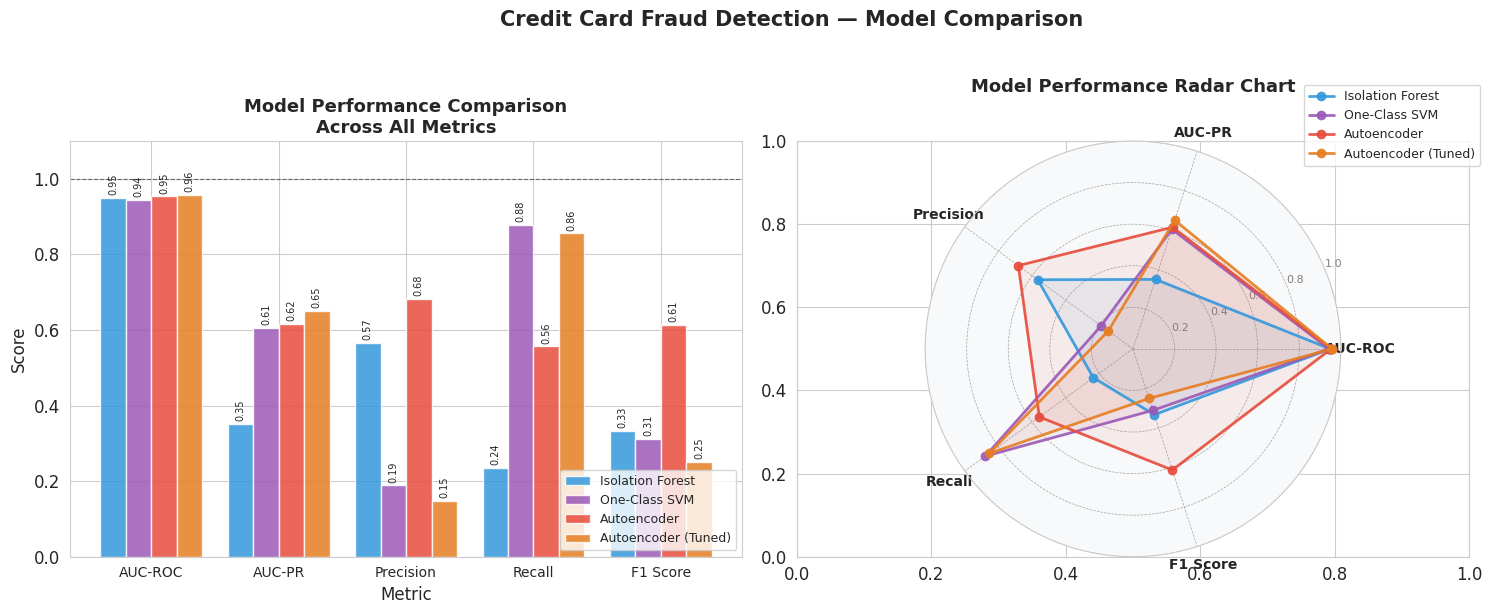

✅ Saved: model_comparison_main.png


In [52]:
# ============================================================
# CELL 47: Visual 1 — Side-by-side metric bar chart
#          The headline chart for your GitHub README
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models  = list(comp_df.index)
metrics = ['AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1 Score']
colors  = ['#3498db', '#9b59b6', '#e74c3c', '#e67e22']
x       = np.arange(len(metrics))
width   = 0.2

# --- Grouped bar chart ---
for i, (model, color) in enumerate(zip(models, colors)):
    vals   = [comp_df.loc[model, m] for m in metrics]
    offset = (i - len(models)/2 + 0.5) * width
    bars   = axes[0].bar(x + offset, vals, width,
                          label=model, color=color,
                          alpha=0.85, edgecolor='white')

axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison\nAcross All Metrics',
                   fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_ylim([0, 1.1])
axes[0].axhline(y=1.0, color='black', linestyle='--',
                linewidth=0.8, alpha=0.5)

# Add value labels on top of bars
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.2f', fontsize=7,
                       padding=2, rotation=90)

# --- Radar / Spider chart ---
categories  = metrics
N           = len(categories)
angles      = [n / float(N) * 2 * np.pi for n in range(N)]
angles     += angles[:1]   # Close the polygon

ax_radar = plt.subplot(122, polar=True)
ax_radar.set_facecolor('#f8f9fa')

for i, (model, color) in enumerate(zip(models, colors)):
    vals  = [comp_df.loc[model, m] for m in metrics]
    vals += vals[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2,
                  color=color, label=model, alpha=0.9)
    ax_radar.fill(angles, vals, alpha=0.08, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'],
                          fontsize=8, color='grey')
ax_radar.set_title('Model Performance Radar Chart\n',
                    fontweight='bold', fontsize=13, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                fontsize=9)
ax_radar.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.suptitle('Credit Card Fraud Detection — Model Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison_main.png")

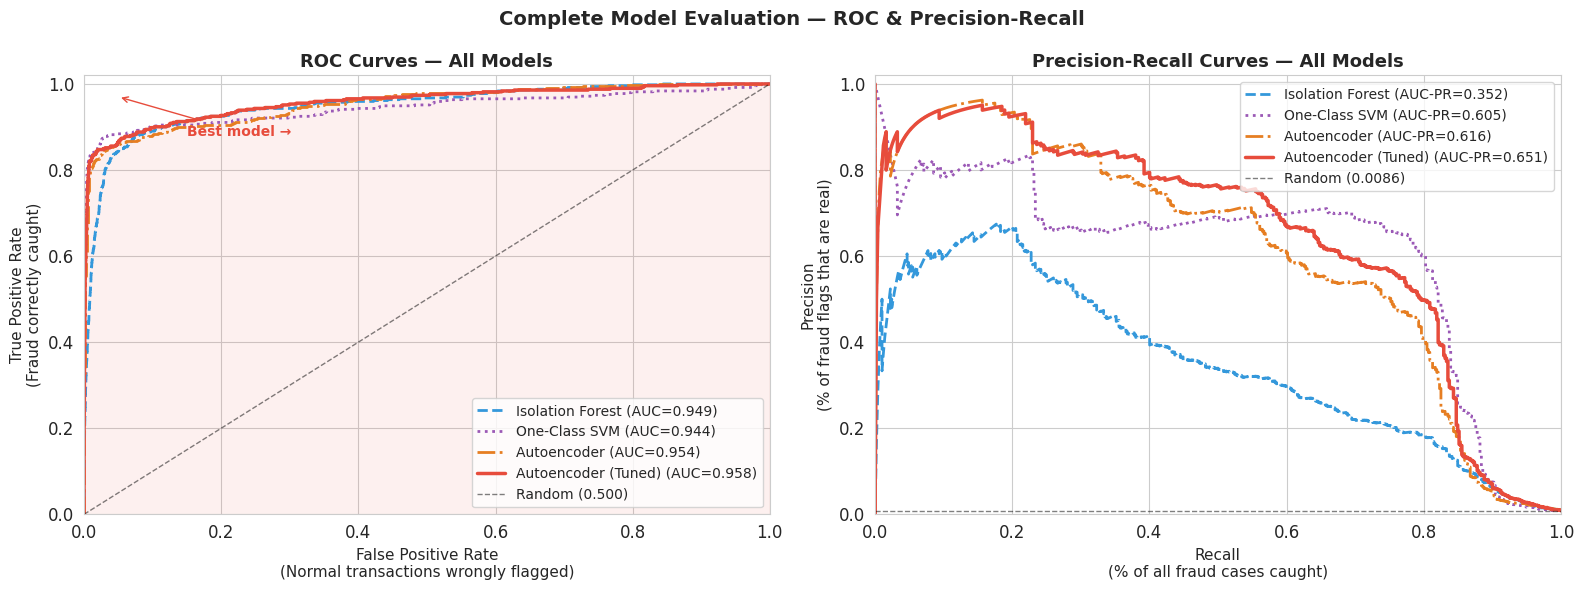

✅ Saved: all_roc_pr_curves.png


In [53]:
# ============================================================
# CELL 48: Visual 2 — All ROC curves on one chart
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gather all scores and labels
score_map = {
    'Isolation Forest'   : if_scores_flipped,
    'One-Class SVM'      : svm_scores_flipped,
    'Autoencoder'        : ae_scores,
    'Autoencoder (Tuned)': tuned_ae_scores,
}
colors_map = {
    'Isolation Forest'   : '#3498db',
    'One-Class SVM'      : '#9b59b6',
    'Autoencoder'        : '#e67e22',
    'Autoencoder (Tuned)': '#e74c3c',
}
styles_map = {
    'Isolation Forest'   : '--',
    'One-Class SVM'      : ':',
    'Autoencoder'        : '-.',
    'Autoencoder (Tuned)': '-',
}

# --- ROC Curves ---
for model, scores in score_map.items():
    fpr, tpr, _ = roc_curve(y_test_np, scores)
    auc          = results[model]['auc_roc']
    axes[0].plot(fpr, tpr,
                 color=colors_map[model],
                 lw=2.5 if 'Tuned' in model else 2,
                 linestyle=styles_map[model],
                 label=f"{model} (AUC={auc:.3f})")

axes[0].fill_between(
    *roc_curve(y_test_np, tuned_ae_scores)[:2],
    alpha=0.08, color='#e74c3c'
)
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate\n(Normal transactions wrongly flagged)',
                    fontsize=11)
axes[0].set_ylabel('True Positive Rate\n(Fraud correctly caught)', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10, loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Annotate best model
axes[0].annotate('Best model →',
                  xy=(0.05, 0.97), xytext=(0.15, 0.88),
                  arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                  fontsize=10, color='#e74c3c', fontweight='bold')

# --- Precision-Recall Curves ---
for model, scores in score_map.items():
    prec, rec, _ = precision_recall_curve(y_test_np, scores)
    auc_pr        = results[model]['auc_pr']
    axes[1].plot(rec, prec,
                 color=colors_map[model],
                 lw=2.5 if 'Tuned' in model else 2,
                 linestyle=styles_map[model],
                 label=f"{model} (AUC-PR={auc_pr:.3f})")

axes[1].axhline(y=y_test_np.mean(), color='k', linestyle='--',
                lw=1, alpha=0.5,
                label=f'Random ({y_test_np.mean():.4f})')
axes[1].set_xlabel('Recall\n(% of all fraud cases caught)', fontsize=11)
axes[1].set_ylabel('Precision\n(% of fraud flags that are real)', fontsize=11)
axes[1].set_title('Precision-Recall Curves — All Models',
                   fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Complete Model Evaluation — ROC & Precision-Recall',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: all_roc_pr_curves.png")

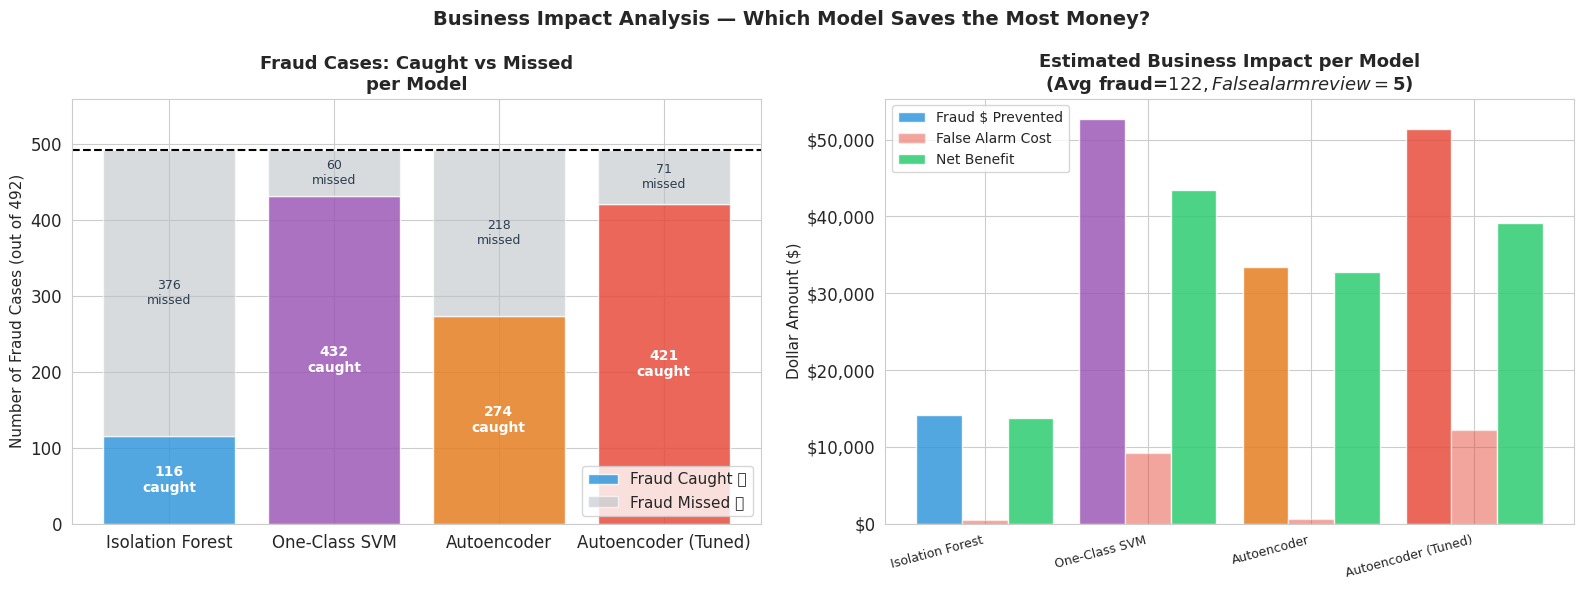

✅ Saved: business_impact.png


In [54]:
# ============================================================
# CELL 49: Visual 3 — Fraud caught vs missed (Business impact)
#          This is the chart non-technical stakeholders care about
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names  = list(results.keys())
caught_vals  = [results[m]['caught'] for m in model_names]
missed_vals  = [results[m]['missed'] for m in model_names]
recall_vals  = [results[m]['recall'] for m in model_names]

bar_colors   = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']

# --- Stacked bar: caught vs missed ---
bars1 = axes[0].bar(model_names, caught_vals,
                     color=bar_colors, alpha=0.85,
                     edgecolor='white', label='Fraud Caught ✅')
bars2 = axes[0].bar(model_names, missed_vals,
                     bottom=caught_vals,
                     color='#bdc3c7', alpha=0.6,
                     edgecolor='white', label='Fraud Missed ❌')

axes[0].set_ylabel('Number of Fraud Cases (out of 492)', fontsize=11)
axes[0].set_title('Fraud Cases: Caught vs Missed\nper Model',
                   fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 560])
axes[0].axhline(y=492, color='black', linestyle='--',
                lw=1.5, label='Total fraud = 492')

for i, (bar, caught, missed) in enumerate(
        zip(bars1, caught_vals, missed_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 caught/2,
                 f'{caught}\ncaught',
                 ha='center', va='center',
                 fontweight='bold', fontsize=10, color='white')
    if missed > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     caught + missed/2,
                     f'{missed}\nmissed',
                     ha='center', va='center',
                     fontsize=9, color='#2c3e50')

plt.xticks(rotation=15, ha='right', fontsize=9)

# --- Business cost chart ---
# Assume average fraud = $122, false alarm cost = $5 (manual review)
AVG_FRAUD_LOSS    = 122
FALSE_ALARM_COST  = 5

business_data = []
for model in model_names:
    r              = results[model]
    fraud_prevented = r['caught'] * AVG_FRAUD_LOSS
    false_alarms    = int(r['caught'] / (r['precision'] + 1e-9)) - r['caught']
    false_alarm_cost= false_alarms * FALSE_ALARM_COST
    net_benefit     = fraud_prevented - false_alarm_cost
    business_data.append({
        'model'         : model,
        'prevented'     : fraud_prevented,
        'fa_cost'       : false_alarm_cost,
        'net'           : net_benefit
    })

biz_df = pd.DataFrame(business_data)

x      = np.arange(len(model_names))
width  = 0.28
axes[1].bar(x - width, biz_df['prevented'], width,
             label='Fraud $ Prevented',
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].bar(x,          biz_df['fa_cost'],  width,
             label='False Alarm Cost',
             color='#e74c3c', alpha=0.5, edgecolor='white')
axes[1].bar(x + width,  biz_df['net'],      width,
             label='Net Benefit',
             color='#2ecc71', alpha=0.85, edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15,
                         ha='right', fontsize=9)
axes[1].set_ylabel('Dollar Amount ($)', fontsize=11)
axes[1].set_title('Estimated Business Impact per Model\n'
                   f'(Avg fraud=${AVG_FRAUD_LOSS}, '
                   f'False alarm review=${FALSE_ALARM_COST})',
                   fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Business Impact Analysis — Which Model Saves the Most Money?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: business_impact.png")

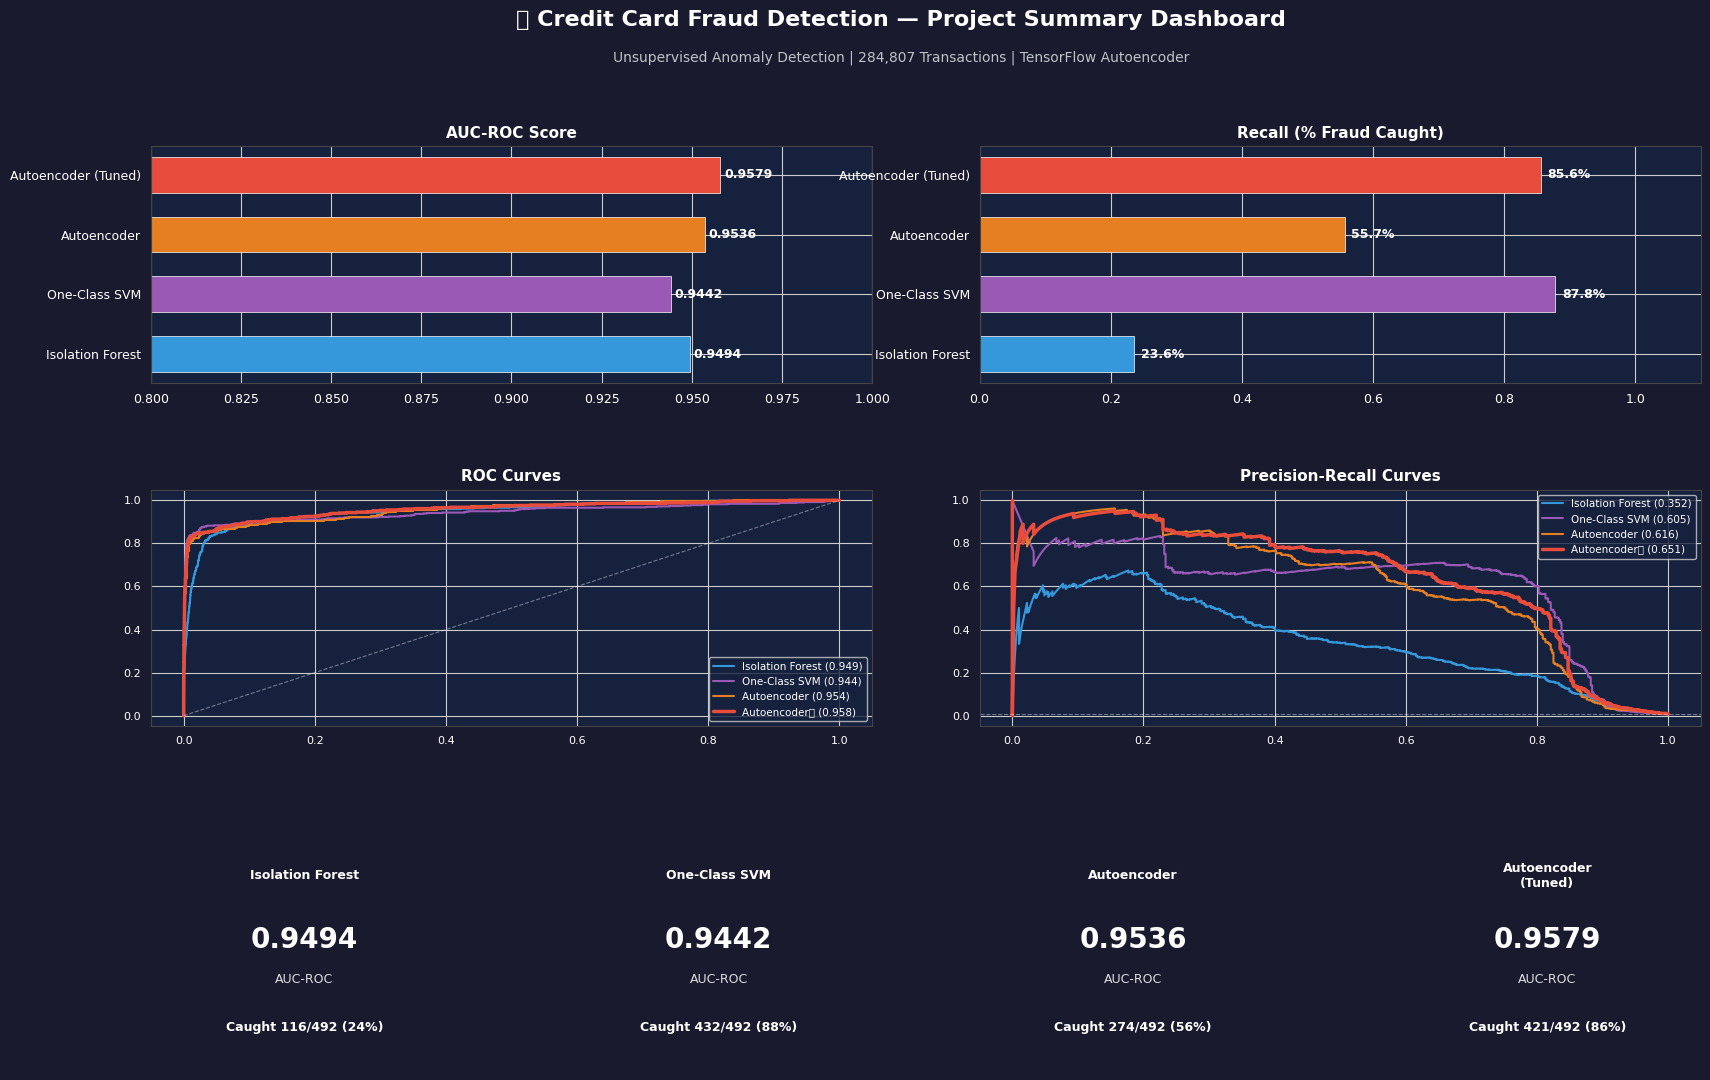

✅ Saved: project_summary_dashboard.png  ← This is your README hero image!


In [55]:
# ============================================================
# CELL 50: Visual 4 — The full project summary dashboard
#          One single image that tells the whole story
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#1a1a2e')

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

title_style  = {'fontweight': 'bold', 'fontsize': 11, 'color': 'white'}
label_style  = {'fontsize': 9,  'color': '#bdc3c7'}

# Colour palette
COLORS = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']

# --- Panel 1: AUC-ROC bar ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#16213e')
bars = ax1.barh(model_names, [results[m]['auc_roc'] for m in model_names],
                color=COLORS, edgecolor='white', linewidth=0.5, height=0.6)
ax1.set_xlim([0.8, 1.0])
ax1.set_title('AUC-ROC Score', **title_style)
ax1.tick_params(colors='white', labelsize=9)
ax1.spines[:].set_color('#444')
for bar, val in zip(bars, [results[m]['auc_roc'] for m in model_names]):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9,
             color='white', fontweight='bold')
ax1.axvline(x=0.5, color='grey', linestyle='--', lw=1, alpha=0.5)

# --- Panel 2: Recall bar ---
ax2 = fig.add_subplot(gs[0, 2:])
ax2.set_facecolor('#16213e')
bars2 = ax2.barh(model_names, [results[m]['recall'] for m in model_names],
                  color=COLORS, edgecolor='white', linewidth=0.5, height=0.6)
ax2.set_xlim([0, 1.1])
ax2.set_title('Recall (% Fraud Caught)', **title_style)
ax2.tick_params(colors='white', labelsize=9)
ax2.spines[:].set_color('#444')
for bar, val in zip(bars2, [results[m]['recall'] for m in model_names]):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=9,
             color='white', fontweight='bold')

# --- Panel 3: ROC curves ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor('#16213e')
for model, color in zip(model_names, COLORS):
    scores    = [if_scores_flipped, svm_scores_flipped,
                 ae_scores, tuned_ae_scores][model_names.index(model)]
    fpr, tpr, _ = roc_curve(y_test_np, scores)
    lw          = 2.5 if 'Tuned' in model else 1.5
    ax3.plot(fpr, tpr, color=color, lw=lw,
             label=f"{model.replace(' (Tuned)', '✨')} "
                   f"({results[model]['auc_roc']:.3f})")
ax3.plot([0,1],[0,1],'w--', lw=0.8, alpha=0.4)
ax3.set_title('ROC Curves', **title_style)
ax3.tick_params(colors='white', labelsize=8)
ax3.spines[:].set_color('#444')
ax3.legend(fontsize=7.5, loc='lower right',
           facecolor='#16213e', labelcolor='white')
ax3.set_facecolor('#16213e')

# --- Panel 4: PR curves ---
ax4 = fig.add_subplot(gs[1, 2:])
ax4.set_facecolor('#16213e')
for model, color in zip(model_names, COLORS):
    scores         = [if_scores_flipped, svm_scores_flipped,
                      ae_scores, tuned_ae_scores][model_names.index(model)]
    prec, rec, _   = precision_recall_curve(y_test_np, scores)
    lw             = 2.5 if 'Tuned' in model else 1.5
    ax4.plot(rec, prec, color=color, lw=lw,
             label=f"{model.replace(' (Tuned)', '✨')} "
                   f"({results[model]['auc_pr']:.3f})")
ax4.axhline(y=y_test_np.mean(), color='white',
            linestyle='--', lw=0.8, alpha=0.4)
ax4.set_title('Precision-Recall Curves', **title_style)
ax4.tick_params(colors='white', labelsize=8)
ax4.spines[:].set_color('#444')
ax4.legend(fontsize=7.5, loc='upper right',
           facecolor='#16213e', labelcolor='white')

# --- Panel 5: Summary stat cards ---
for idx, (model, color) in enumerate(zip(model_names, COLORS)):
    ax = fig.add_subplot(gs[2, idx])
    ax.set_facecolor(color)
    ax.axis('off')
    r   = results[model]
    pct = r['caught'] / 492 * 100
    ax.text(0.5, 0.82, model.replace(' (Tuned)', '\n(Tuned)'),
            ha='center', va='center', transform=ax.transAxes,
            fontsize=9, fontweight='bold', color='white')
    ax.text(0.5, 0.55, f"{r['auc_roc']:.4f}",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=20, fontweight='bold', color='white')
    ax.text(0.5, 0.38, 'AUC-ROC',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=9, color='white', alpha=0.85)
    ax.text(0.5, 0.18, f"Caught {r['caught']}/492 ({pct:.0f}%)",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=9, color='white', fontweight='bold')

fig.text(0.5, 0.98,
         '🔍 Credit Card Fraud Detection — Project Summary Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.95,
         'Unsupervised Anomaly Detection | 284,807 Transactions | '
         'TensorFlow Autoencoder',
         ha='center', fontsize=10, color='#bdc3c7')

plt.savefig('project_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Saved: project_summary_dashboard.png  ← This is your README hero image!")

In [56]:
# ============================================================
# CELL 51: Print the final comparison table cleanly
#          Copy this into your README
# ============================================================

print("\n" + "=" * 70)
print("   FINAL MODEL COMPARISON — Copy this into your GitHub README")
print("=" * 70)
print(f"\n{'Model':<26} {'AUC-ROC':>8} {'AUC-PR':>8} "
      f"{'Recall':>8} {'Precision':>10} {'F1':>7}")
print("-" * 70)
for model, r in results.items():
    f1     = round(2 * r['precision'] * r['recall'] /
              (r['precision'] + r['recall'] + 1e-9), 4)
    marker = ' ← BEST' if r['auc_roc'] == max(
               v['auc_roc'] for v in results.values()) else ''
    print(f"{model:<26} {r['auc_roc']:>8.4f} {r['auc_pr']:>8.4f} "
          f"{r['recall']:>8.4f} {r['precision']:>10.4f} "
          f"{f1:>7.4f}{marker}")
print("-" * 70)
print(f"{'Random Baseline':<26} {'0.5000':>8} {'0.0086':>8} "
      f"{'~0.17%':>8} {'N/A':>10} {'N/A':>7}")

print(f"""
📁 Files saved this step:
   model_comparison_main.png   ← Grouped bars + radar chart
   all_roc_pr_curves.png       ← All 4 models' curves together
   business_impact.png         ← Dollar value analysis
   project_summary_dashboard.png ← Hero image for README 🌟
""")


   FINAL MODEL COMPARISON — Copy this into your GitHub README

Model                       AUC-ROC   AUC-PR   Recall  Precision      F1
----------------------------------------------------------------------
Isolation Forest             0.9494   0.3516   0.2358     0.5659  0.3329
One-Class SVM                0.9442   0.6054   0.8780     0.1890  0.3110
Autoencoder                  0.9536   0.6156   0.5569     0.6816  0.6130
Autoencoder (Tuned)          0.9579   0.6507   0.8557     0.1468  0.2506 ← BEST
----------------------------------------------------------------------
Random Baseline              0.5000   0.0086   ~0.17%        N/A     N/A

📁 Files saved this step:
   model_comparison_main.png   ← Grouped bars + radar chart
   all_roc_pr_curves.png       ← All 4 models' curves together
   business_impact.png         ← Dollar value analysis
   project_summary_dashboard.png ← Hero image for README 🌟



In [58]:
# ============================================================
# CELL 52: Save everything needed for the app from Colab
# ============================================================

import pickle
import numpy as np
import json

# Save the threshold and scaler info the app needs
app_config = {
    'threshold'        : float(best_threshold),
    'feature_names'    : list(X_train.columns),
    'input_dim'        : int(X_train_np.shape[1]),
    'fraud_mean_error' : float(reconstruction_errors[y_test_np==1].mean()),
    'normal_mean_error': float(reconstruction_errors[y_test_np==0].mean()),
    'model_results'    : {
        k: {mk: float(mv) if isinstance(mv, (np.floating, float))
            else int(mv) if isinstance(mv, (np.integer, int))
            else mv
            for mk, mv in v.items()}
        for k, v in results.items()
    }
}

with open('app_config.json', 'w') as f:
    json.dump(app_config, f, indent=2)

print("✅ App config saved!")
print(f"   Threshold       : {app_config['threshold']:.6f}")
print(f"   Features        : {app_config['input_dim']}")
print(f"   Normal mean err : {app_config['normal_mean_error']:.6f}")
print(f"   Fraud  mean err : {app_config['fraud_mean_error']:.6f}")

# Download all app files from Colab to your computer
from google.colab import files
files.download('best_tuned_autoencoder.keras')
files.download('app_config.json')
print("\n✅ Download these two files — you need them for the app!")

✅ App config saved!
   Threshold       : 6.624415
   Features        : 30
   Normal mean err : 0.462763
   Fraud  mean err : 19.268066


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download these two files — you need them for the app!


In [59]:
# ============================================================
# CELL 53: Save weights only — works across ALL Keras versions
# ============================================================

# Save weights (tiny file, version-independent)
best_autoencoder.save_weights('autoencoder_weights.weights.h5')

# Save architecture as JSON (plain text, always compatible)
model_json = best_autoencoder.to_json()
with open('model_architecture.json', 'w') as f:
    f.write(model_json)

# Save the best params so app can rebuild the model
import json
best_params_save = {
    'enc1'        : int(tuning_df.iloc[0]['encoding_dim_1']),
    'enc2'        : int(tuning_df.iloc[0]['encoding_dim_2']),
    'bottleneck'  : int(tuning_df.iloc[0]['bottleneck']),
    'dropout_rate': float(tuning_df.iloc[0]['dropout_rate']),
    'input_dim'   : int(X_train_np.shape[1])
}
with open('model_params.json', 'w') as f:
    json.dump(best_params_save, f)

print("Best params:", best_params_save)
print("✅ Done! Downloading now...")

from google.colab import files
files.download('autoencoder_weights.weights.h5')
files.download('model_params.json')

Best params: {'enc1': 32, 'enc2': 8, 'bottleneck': 4, 'dropout_rate': 0.2, 'input_dim': 30}
✅ Done! Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>